# Section 1 AirLine


## **Imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import warnings
warnings.filterwarnings('ignore')

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

for resource in ['punkt','punkt_tab','stopwords','wordnet','omw-1.4']:
    nltk.download(resource, quiet=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("All imports done.")

All imports done.


## **Load Dataset**

In [ ]:
DATASET_NAME1 = "mexwell/skytrax-user-reviews-dataset"
FILE_PATH1    = "airline.csv"

df1_raw = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    DATASET_NAME1, FILE_PATH1
)

df1 = pd.DataFrame({
    'Review'               : df1_raw['content'],
    'Country'              : df1_raw['author_country'],
    'Verified'             : True,
    'Seat Type'            : df1_raw['cabin_flown'],
    'Seat Comfort'         : df1_raw['seat_comfort_rating'],
    'Cabin Staff Service'  : df1_raw['cabin_staff_rating'],
    'Food & Beverages'     : df1_raw['food_beverages_rating'],
    'Inflight Entertainment': df1_raw['inflight_entertainment_rating'],
    'Ground Service'       : df1_raw['ground_service_rating'],
    'Wifi & Connectivity'  : df1_raw['wifi_connectivity_rating'],
    'Value For Money'      : df1_raw['value_money_rating'],
    'Recommended'          : df1_raw['recommended'].map({1:'yes', 0:'no'})
})

print("Shape:", df1.shape)
df1.head()

100%|██████████| 10.7M/10.7M [00:00<00:00, 51.4MB/s]

Extracting zip of airline.csv...


Shape: (41396, 12)


,Review,Country,Verified,Seat Type,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended
0,Outbound flight FRA/PRN A319. 2 hours 10 min f...,Germany,True,Economy,4.0,4.0,4.0,0.0,NaN,NaN,4.0,yes
1,Two short hops ZRH-LJU and LJU-VIE. Very fast ...,United States,True,Business Class,4.0,5.0,4.0,1.0,NaN,NaN,5.0,yes
2,Flew Zurich-Ljubljana on JP365 newish CRJ900. ...,Switzerland,True,Economy,5.0,5.0,4.0,0.0,NaN,NaN,5.0,yes
3,Adria serves this 100 min flight from Ljubljan...,Singapore,True,Business Class,4.0,4.0,3.0,1.0,NaN,NaN,4.0,yes
4,WAW-SKJ Economy. No free snacks or drinks on t...,Poland,True,Economy,4.0,2.0,1.0,2.0,NaN,NaN,2.0,no


## **EDA - Understand Dataset**

In [ ]:
print("=== SHAPE ===")
print(df1.shape)

print("\n=== NUMERIC SUMMARY ===")
print(df1.describe().round(2))

print("\n=== CATEGORICAL SUMMARY ===")
print(df1.describe(include='object'))

=== SHAPE ===
(41396, 12)

=== NUMERIC SUMMARY ===
       Seat Comfort  Cabin Staff Service  Food & Beverages  \
count      33706.00             33708.00          33264.00   
mean           3.09                 3.32              2.81   
std            1.41                 1.54              1.58   
min            0.00                 0.00              0.00   
25%            2.00                 2.00              1.00   
50%            3.00                 4.00              3.00   
75%            4.00                 5.00              4.00   
max            5.00                 5.00              5.00   

       Inflight Entertainment  Ground Service  Wifi & Connectivity  \
count                31114.00         2203.00               565.00   
mean                     2.39            2.74                 2.25   
std                      1.70            1.57                 1.54   
min                      0.00            1.00                 1.00   
25%                      1.00           

                        missing_count  missing_pct
Wifi & Connectivity             40831        98.64
Ground Service                  39193        94.68
Inflight Entertainment          10282        24.84
Food & Beverages                 8132        19.64
Seat Comfort                     7690        18.58
Cabin Staff Service              7688        18.57
Seat Type                        2876         6.95
Value For Money                  1673         4.04
Country                          1591         3.84


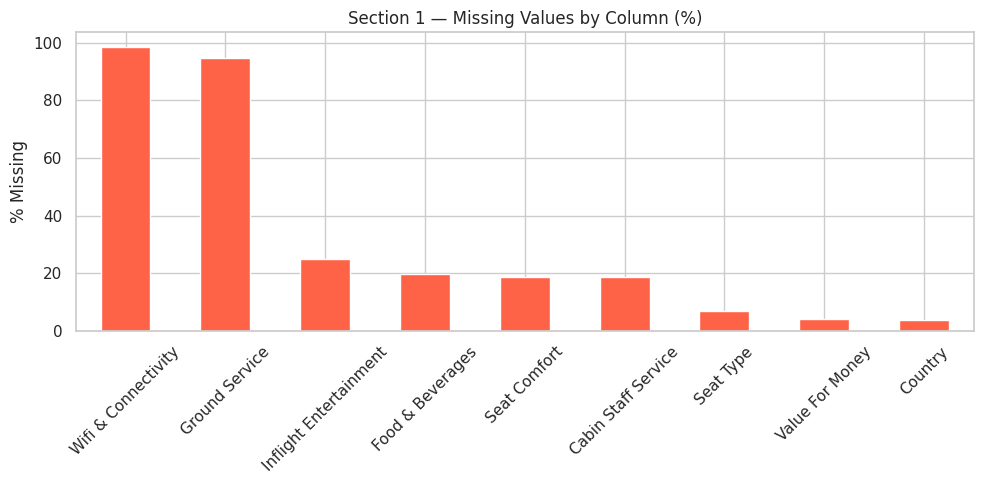

In [ ]:
missing1     = df1.isnull().sum()
missing1_pct = (missing1 / len(df1) * 100).round(2)
missing1_df  = pd.DataFrame({
    'missing_count': missing1,
    'missing_pct'  : missing1_pct
})
missing1_df = missing1_df[
    missing1_df['missing_count'] > 0
].sort_values('missing_pct', ascending=False)

print(missing1_df)

missing1_df['missing_pct'].plot(kind='bar', color='tomato',
                                figsize=(10, 5))
plt.title('Section 1 — Missing Values by Column (%)')
plt.ylabel('% Missing')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== Recommended Distribution ===
Recommended
yes    22098
no     19298
Name: count, dtype: int64
Recommended
yes    53.4
no     46.6
Name: proportion, dtype: float64


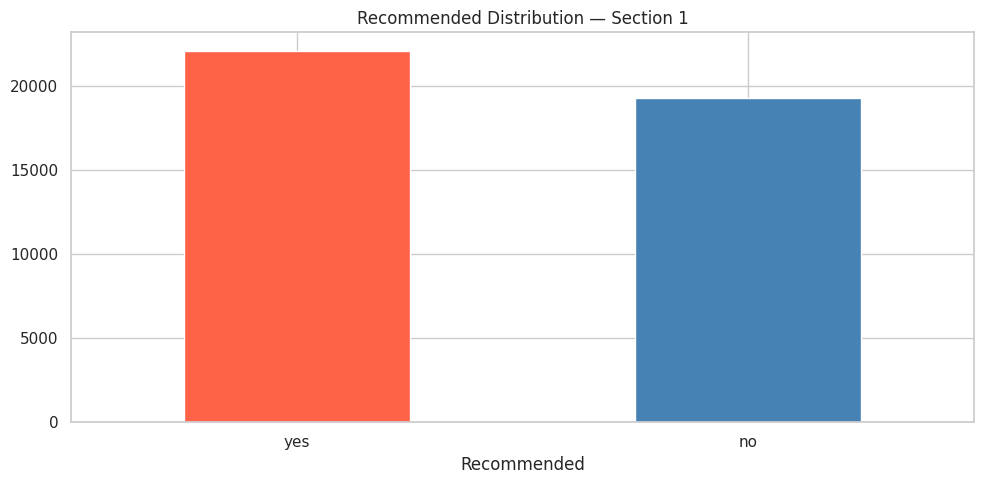

In [ ]:
print("=== Recommended Distribution ===")
print(df1['Recommended'].value_counts())
print(df1['Recommended'].value_counts(normalize=True).round(3) * 100)

df1['Recommended'].value_counts().plot(
    kind='bar', color=['tomato','steelblue'])
plt.title('Recommended Distribution — Section 1')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

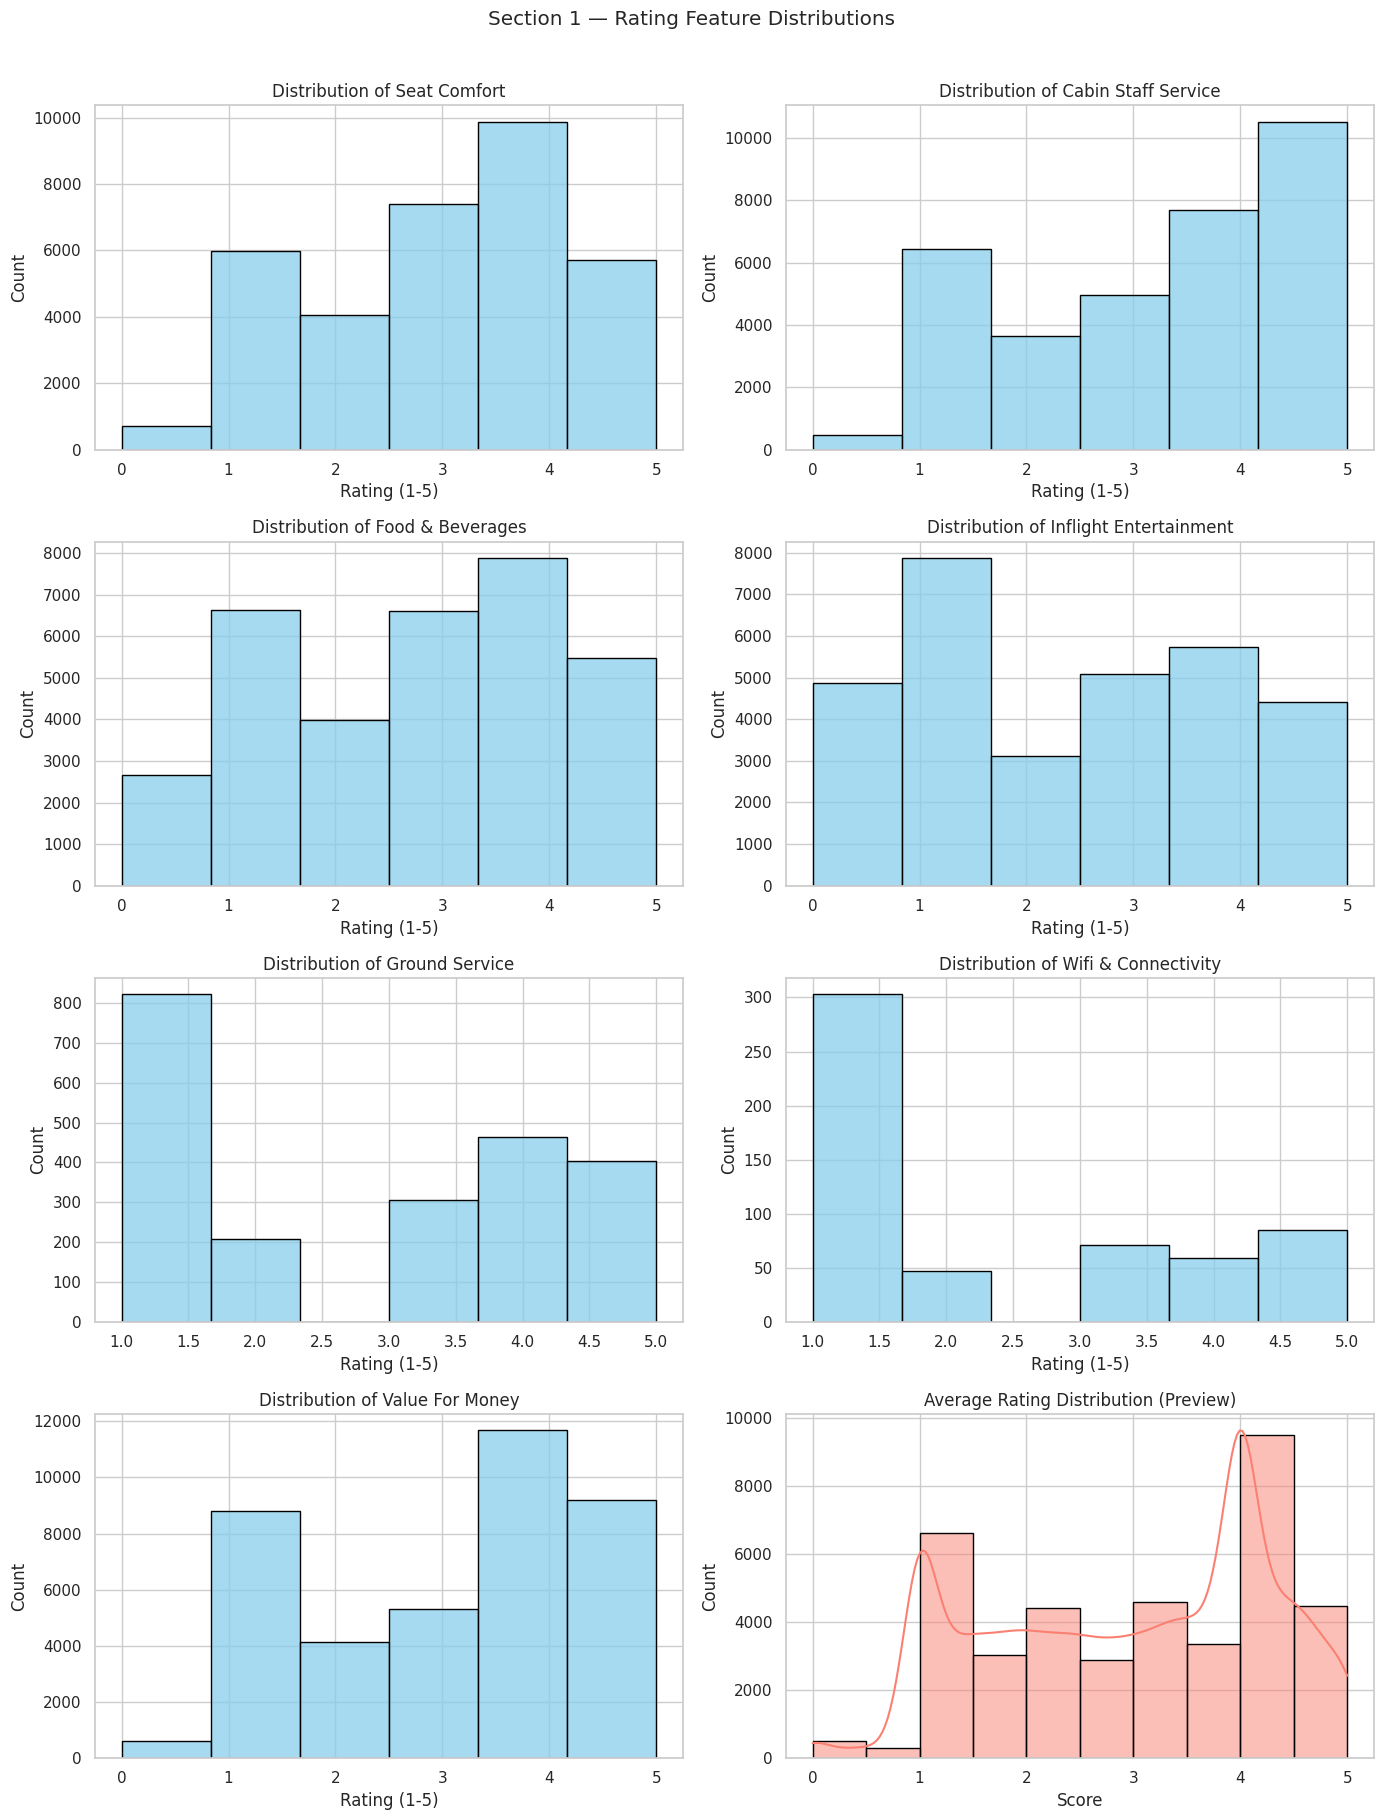

In [ ]:
rating_cols1 = ['Seat Comfort', 'Cabin Staff Service',
                'Food & Beverages', 'Inflight Entertainment',
                'Ground Service', 'Wifi & Connectivity',
                'Value For Money']

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(rating_cols1):
    sns.histplot(df1[col].dropna(), bins=6, kde=False,
                 ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Rating (1-5)')
    axes[i].set_ylabel('Count')

avg_preview1 = df1[rating_cols1].mean(axis=1)
sns.histplot(avg_preview1.dropna(), bins=10, kde=True,
             ax=axes[7], color='salmon', edgecolor='black')
axes[7].set_title('Average Rating Distribution (Preview)')
axes[7].set_xlabel('Score')

plt.suptitle('Section 1 — Rating Feature Distributions', y=1.01)
plt.tight_layout()
plt.show()

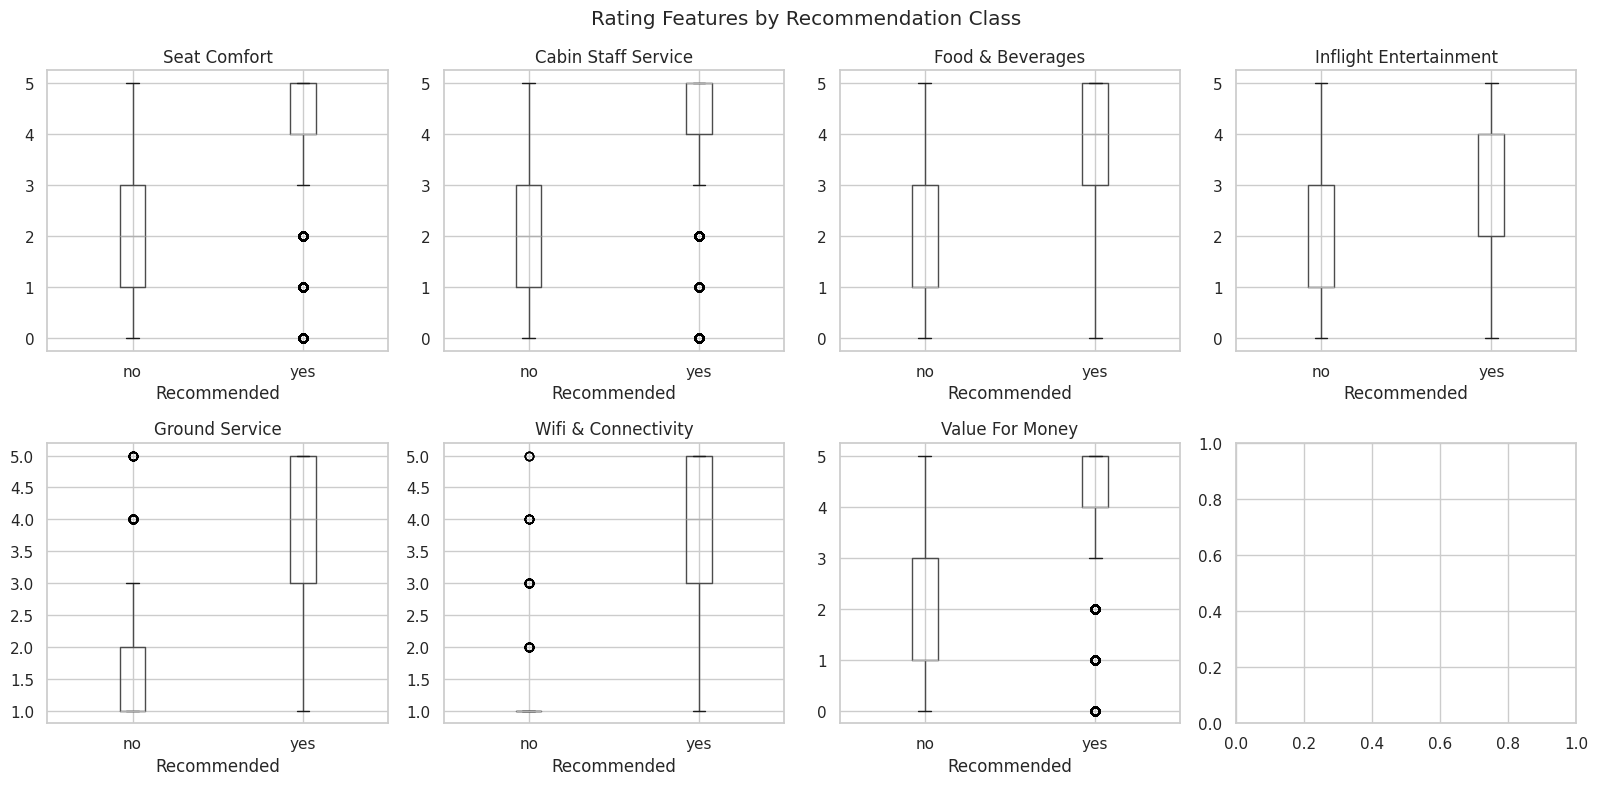

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(rating_cols1[:8]):
    df1.boxplot(column=col, by='Recommended', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Recommended')

plt.suptitle('Rating Features by Recommendation Class')
plt.tight_layout()
plt.show()

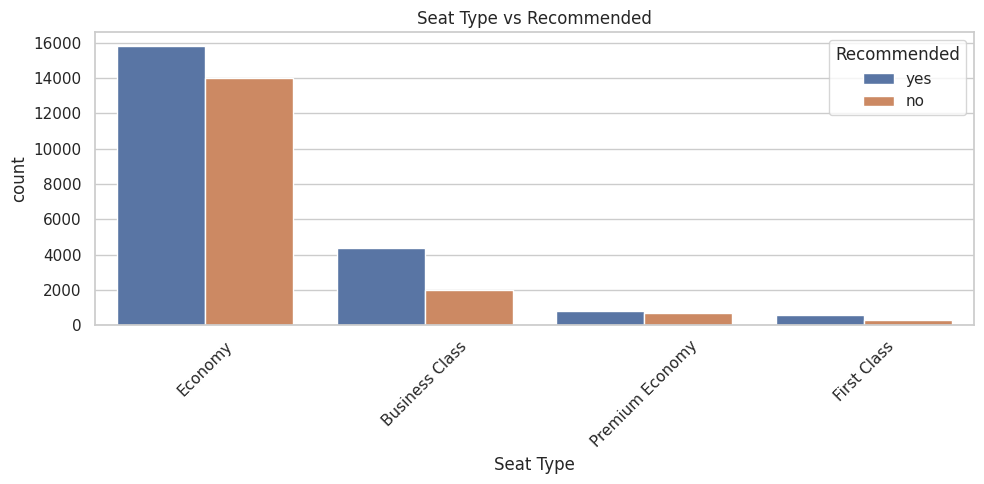

In [ ]:
for col in ['Seat Type']:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, hue='Recommended', data=df1)
    plt.title(f'{col} vs Recommended')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

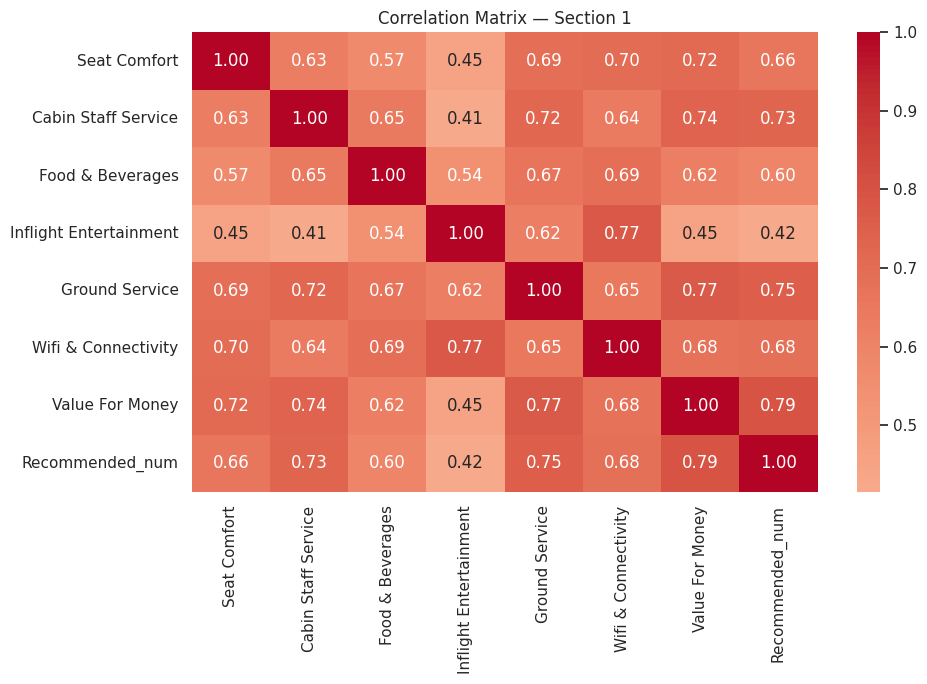

In [ ]:
df1_corr = df1.copy()
df1_corr['Recommended_num'] = df1_corr['Recommended'].map(
    {'yes': 1, 'no': 0})

corr1 = df1_corr[rating_cols1 + ['Recommended_num']].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr1, annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Section 1')
plt.tight_layout()
plt.show()

## **Data Cleaning**

In [ ]:
df1_clean = df1.copy()

df1_clean = df1_clean.drop_duplicates()
df1_clean = df1_clean.drop_duplicates(subset='Review', keep='first')
print("After duplicates:", df1_clean.shape)

df1_clean['Review'] = df1_clean['Review'].str.replace(
    r'^.*?\|', '', regex=True).str.strip()

drop1 = ['Recommended',
         'Wifi & Connectivity',
         'Ground Service']
df1_clean = df1_clean.drop(columns=drop1, errors='ignore')
print("After dropping columns:", df1_clean.shape)

rating_cols1_clean = ['Seat Comfort', 'Cabin Staff Service',
                      'Food & Beverages', 'Inflight Entertainment',
                      'Value For Money']

df1_clean['avg_rating'] = df1_clean[rating_cols1_clean].mean(axis=1)

def rating_to_sentiment(score):
    if pd.isna(score):    return None
    elif score >= 4.0:    return 'Positive'
    elif score >= 2.5:    return 'Neutral'
    else:                 return 'Negative'

df1_clean['sentiment'] = df1_clean['avg_rating'].apply(
    rating_to_sentiment)

df1_clean = df1_clean.dropna(subset=['sentiment'])
print("After dropping null sentiment:", df1_clean.shape)

for col in rating_cols1_clean:
    df1_clean[col] = df1_clean[col].fillna(df1_clean[col].median())

for col in ['Country', 'Seat Type']:
    if col in df1_clean.columns:
        df1_clean[col] = df1_clean[col].fillna(
            df1_clean[col].mode()[0])

df1_clean = df1_clean.drop(columns=['avg_rating'])

print("\nMissing after cleaning:")
print(df1_clean.isnull().sum())
print("\nFinal shape:", df1_clean.shape)
print("Columns:", df1_clean.columns.tolist())

print("\nSentiment Distribution:")
print(df1_clean['sentiment'].value_counts())
print(df1_clean['sentiment'].value_counts(normalize=True).round(3)*100)

After duplicates: (41362, 12)
After dropping columns: (41362, 9)
After dropping null sentiment: (39696, 11)

Missing after cleaning:
Review                    0
Country                   0
Verified                  0
Seat Type                 0
Seat Comfort              0
Cabin Staff Service       0
Food & Beverages          0
Inflight Entertainment    0
Value For Money           0
sentiment                 0
dtype: int64

Final shape: (39696, 10)
Columns: ['Review', 'Country', 'Verified', 'Seat Type', 'Seat Comfort', 'Cabin Staff Service', 'Food & Beverages', 'Inflight Entertainment', 'Value For Money', 'sentiment']

Sentiment Distribution:
sentiment
Negative    14881
Positive    13992
Neutral     10823
Name: count, dtype: int64
sentiment
Negative    37.5
Positive    35.2
Neutral     27.3
Name: proportion, dtype: float64


## **Feature Selection**

=== Feature Importance Scores — Section 1 ===
               feature        score
       Value For Money 44469.221446
   Cabin Staff Service 21101.399108
      Food & Beverages 18111.702256
          Seat Comfort 16155.794132
Inflight Entertainment  9667.324965


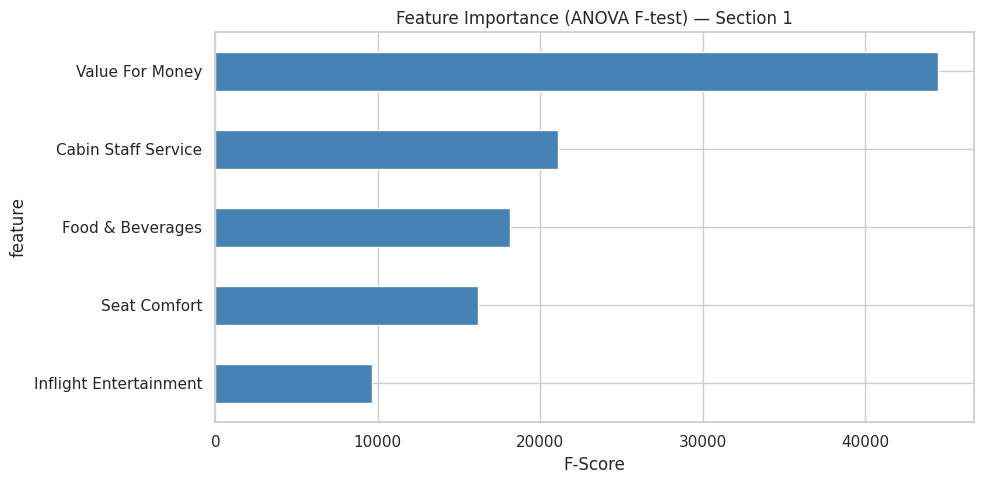

In [ ]:
# ── Feature Selection ─────────────────────────────────────────
X1_fs    = df1_clean[rating_cols1_clean].fillna(0)
le1_temp = LabelEncoder()
y1_fs    = le1_temp.fit_transform(df1_clean['sentiment'])

selector1 = SelectKBest(score_func=f_classif, k='all')
selector1.fit(X1_fs, y1_fs)

feature_scores1 = pd.DataFrame({
    'feature': rating_cols1_clean,
    'score'  : selector1.scores_
}).sort_values('score', ascending=False)

print("=== Feature Importance Scores — Section 1 ===")
print(feature_scores1.to_string(index=False))

feature_scores1.set_index('feature')['score'].plot(
    kind='barh', color='steelblue')
plt.title('Feature Importance (ANOVA F-test) — Section 1')
plt.xlabel('F-Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## **Data Preprocessing & NLP Pipeline**
## Text Preprocessing (NLP Pipeline)
### Steps applied:
1. **Lowercase conversion**: Uniformity for text matching.
2. **Clean-up**: Remove URLs, emails, and special characters.
3. **Tokenization**: Breaking text into individual words.
4. **Stopword removal**: Removing common words while preserving negations (e.g., 'not').
5. **Lemmatization**: Reducing words to their base root form.
6. **TF-IDF Vectorization**: Converting text to numeric vectors with unigrams and bigrams.

In [ ]:
lemmatizer1  = WordNetLemmatizer()
stop_words1  = set(stopwords.words('english'))
negations    = {'not','no','never','neither','nor',
                'barely','hardly','scarcely'}
stop_words1  = stop_words1 - negations

def preprocess_text(text):
    """
    Full NLP pipeline:
    1. Lowercase
    2. Remove URLs, emails, special chars
    3. Tokenize
    4. Remove stopwords (keep negations)
    5. Lemmatize
    6. Rejoin
    """
    if pd.isna(text):
        return ""
    text   = text.lower()
    text   = re.sub(r'http\S+|www\S+|\S+@\S+', '', text)
    text   = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words1]
    tokens = [lemmatizer1.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


examples = [
    "The cabin crew were excellent and very friendly",
    "Terrible flight, delayed 3 hours, rude staff",
    "The food was not good at all",
]
print("=== NLP Preprocessing Examples ===\n")
for ex in examples:
    print(f"Original : {ex}")
    print(f"Cleaned  : {preprocess_text(ex)}")
    print()

=== NLP Preprocessing Examples ===

Original : The cabin crew were excellent and very friendly
Cleaned  : cabin crew excellent friendly

Original : Terrible flight, delayed 3 hours, rude staff
Cleaned  : terrible flight delayed hour rude staff

Original : The food was not good at all
Cleaned  : food not good



In [ ]:

df1_processed = df1_clean.copy()

print("Applying NLP preprocessing — please wait...")
df1_processed['Review_cleaned'] = df1_processed['Review'].apply(
    preprocess_text)

print("\n=== Before vs After ===")
for i in range(3):
    print(f"BEFORE: {df1_processed['Review'].iloc[i][:100]}")
    print(f"AFTER : {df1_processed['Review_cleaned'].iloc[i][:100]}")
    print()
print("Done! Shape:", df1_processed.shape)

Applying NLP preprocessing — please wait...

=== Before vs After ===
BEFORE: Outbound flight FRA/PRN A319. 2 hours 10 min flight. I thought drinks/snacks for sale but sandwich s
AFTER : outbound flight fraprn hour min flight thought drinkssnacks sale sandwich soft drink served complime

BEFORE: Two short hops ZRH-LJU and LJU-VIE. Very fast on CRJ 90. Seats comfortable and crew was fine. Ground
AFTER : two short hop zrhlju ljuvie fast crj seat comfortable crew fine ground service good lounge quite nic

BEFORE: Flew Zurich-Ljubljana on JP365 newish CRJ900. Flight almost full departure on time. Service on board
AFTER : flew zurichljubljana jp newish crj flight almost full departure time service board pleasant friendly

Done! Shape: (39696, 11)


## **Feature Engineering**


In [ ]:
# ── Feature Engineering ───────────────────────────────────────
# Text-based features
df1_processed['review_length'] = df1_processed['Review'].apply(len)
df1_processed['word_count']    = df1_processed['Review'].apply(
    lambda x: len(x.split()))

# Rating aggregate features
df1_processed['overall_rating_mean'] = df1_processed[
    rating_cols1_clean].mean(axis=1)
df1_processed['rating_std'] = df1_processed[
    rating_cols1_clean].std(axis=1)

print("Feature Engineering done!")
print("Shape:", df1_processed.shape)
print("Review column exists:", 'Review_cleaned' in df1_processed.columns)

Feature Engineering done!
Shape: (39696, 15)
Review column exists: True


## Train models

In [ ]:
le1 = LabelEncoder()
y1  = le1.fit_transform(df1_processed['sentiment'])
print("Classes:", le1.classes_)

X1_train_text, X1_test_text, y1_train, y1_test = train_test_split(
    df1_processed['Review_cleaned'].astype(str), y1,
    test_size=0.2, random_state=42, stratify=y1
)

tfidf1 = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),
    stop_words=None,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X1_train_final = tfidf1.fit_transform(X1_train_text)
X1_test_final  = tfidf1.transform(X1_test_text)

print(f"Train size: {len(y1_train)}")
print(f"Test size : {len(y1_test)}")
print("Train shape:", X1_train_final.shape)
print("Test shape :", X1_test_final.shape)

Classes: ['Negative' 'Neutral' 'Positive']
Train size: 31756
Test size : 7940
Train shape: (31756, 1000)
Test shape : (7940, 1000)


In [ ]:
models1 = {
    'Logistic Regression' : LogisticRegression(max_iter=1000,
                                               C=1.0,
                                               random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=10,
                                                   random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100,
                                                   max_depth=15,
                                                   random_state=42),
    'Naive Bayes'         : MultinomialNB(),
    'SGD Classifier'      : SGDClassifier(max_iter=1000,
                                          random_state=42),
}

results1 = []

for name, model in models1.items():
    print(f"Training: {name}...")
    model.fit(X1_train_final, y1_train)
    y1_pred = model.predict(X1_test_final)

    results1.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y1_test, y1_pred),
        'Precision': precision_score(y1_test, y1_pred,
                                    average='weighted',
                                    zero_division=0),
        'Recall'   : recall_score(y1_test, y1_pred,
                                 average='weighted',
                                 zero_division=0),
        'F1'       : f1_score(y1_test, y1_pred,
                             average='weighted',
                             zero_division=0),
    })
    print(f"  ✅ F1: {results1[-1]['F1']:.4f}")

print("\nAll Section 1 models trained!")

Training: Logistic Regression...
  ✅ F1: 0.6798
Training: Decision Tree...
  ✅ F1: 0.5740
Training: Random Forest...
  ✅ F1: 0.5607
Training: Naive Bayes...
  ✅ F1: 0.6154
Training: SGD Classifier...
  ✅ F1: 0.5828

All Section 1 models trained!


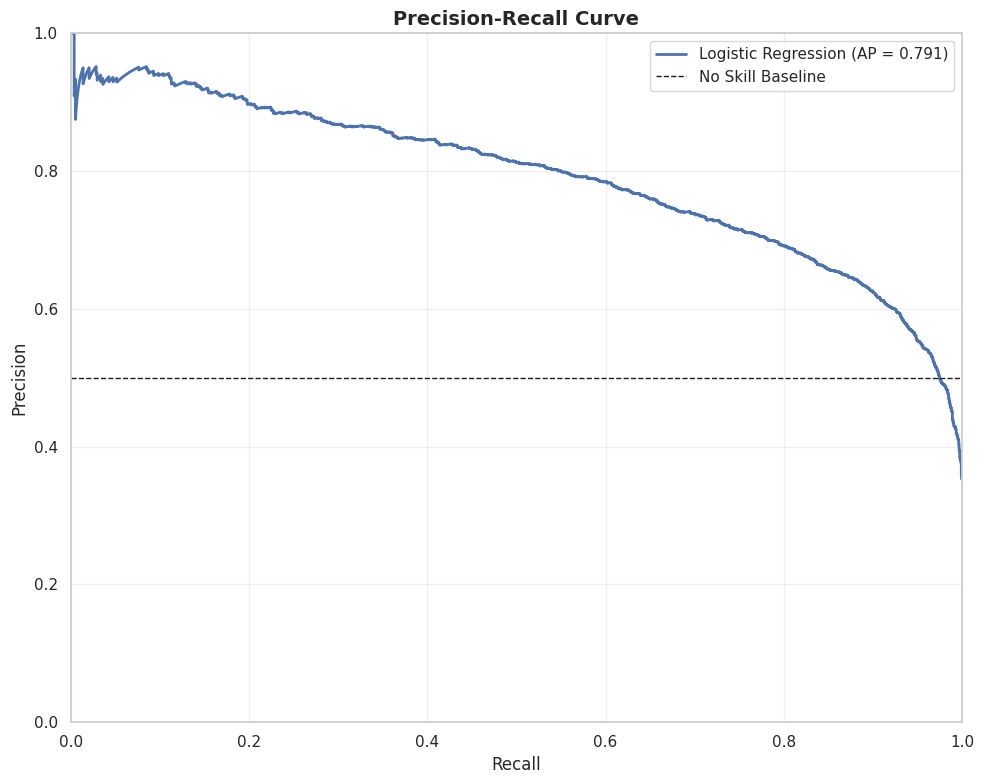

✅ Precision-Recall curve saved as 'precision_recall_curve.png'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Image downloaded to your computer


<Figure size 1000x500 with 0 Axes>

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Added for pd.DataFrame

# Ensure best1_model and best1_name are defined
# Assuming 'results1' and 'models1' are already available from previous executions (Cell NqiwMD0BqvuX)
results1_df = pd.DataFrame(results1).set_index('Model')
results1_df = results1_df.sort_values('F1', ascending=False).round(4)
best1_name  = results1_df.index[0]
best1_model = models1[best1_name]

# Make sure you have your train/test data ready
# X_train_tfidf, X_test_tfidf, y_train, y_test should already exist

# Convert labels to binary (0 for Negative, 1 for Positive)
# The original y1_test contains numerical labels (0, 1, 2) as defined by le1
# 'Positive' corresponds to le1.transform(['Positive'])[0]
positive_label_index = le1.transform(['Positive'])[0]
y_test_binary = (y1_test == positive_label_index).astype(int)

# Get probability predictions from your trained model
# Using the best model from Section 1, which is best1_model, and X1_test_final
# Ensure the best1_model has predict_proba
if hasattr(best1_model, 'predict_proba'):
    y_scores = best1_model.predict_proba(X1_test_final)[:, positive_label_index] # Use the index for 'Positive' class
else:
    # Fallback if the model does not have predict_proba (e.g., some SGD configurations)
    print(f"Warning: {best1_name} does not have predict_proba. Using decision_function if available.")
    if hasattr(best1_model, 'decision_function'):
        y_scores = best1_model.decision_function(X1_test_final)
    else:
        raise ValueError("Model does not support probability prediction or decision function.")


# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test_binary, y_scores)

# Calculate Average Precision (AP)
average_precision = average_precision_score(y_test_binary, y_scores)

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 8))

# Plot the curve
plt.plot(recall, precision, 'b-', linewidth=2,
         label=f'{best1_name} (AP = {average_precision:.3f})') # Use best1_name for label

# Add a no-skill baseline (random classifier)
plt.plot([0, 1], [0.5, 0.5], 'k--', linewidth=1, label='No Skill Baseline')

# Add labels and title
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])

plt.tight_layout()
plt.show()

# Save the figure
plt.savefig('precision_recall_curve.png', dpi=300, bbox_inches='tight')
print("✅ Precision-Recall curve saved as 'precision_recall_curve.png'")

# Download (if using Colab)
try:
    from google.colab import files
    files.download('precision_recall_curve.png')
    print("✅ Image downloaded to your computer")
except:
    print("⚠️ Not in Colab, image saved locally")

## Evaluation

In [ ]:
results1_df = pd.DataFrame(results1).set_index('Model')
results1_df = results1_df.sort_values('F1',
                                      ascending=False).round(4)

print("=== Section 1 — Skytrax Results ===")
print(results1_df.to_string())

results1_df[['Accuracy','Precision','Recall','F1']].plot(
    kind='bar', figsize=(13, 6), ylim=(0, 1.1))
plt.title('Section 1 — Skytrax Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
best1_name  = results1_df.index[0]
best1_model = models1[best1_name]
y1_pred_best = best1_model.predict(X1_test_final)

print(f"Best Model: {best1_name}\n")
print(classification_report(y1_test, y1_pred_best,
                            target_names=le1.classes_))

In [ ]:
for name, model in models1.items():
    y_pred = model.predict(X1_test_final)
    cm = confusion_matrix(y1_test, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le1.classes_,
                yticklabels=le1.classes_)
    plt.title(f'Section 1 — Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

In [ ]:
if hasattr(best1_model, 'feature_importances_'):

    tfidf_feature_names = tfidf1.get_feature_names_out()
    all_numeric_ohe_features = [] # Models trained only on TF-IDF features

    feature_names_for_best_model = list(tfidf_feature_names) + all_numeric_ohe_features

    if len(best1_model.feature_importances_) != len(feature_names_for_best_model):
        print(f"ERROR: Mismatch in feature importance length ({len(best1_model.feature_importances_)}) ")
        print(f"and feature name list length ({len(feature_names_for_best_model)}).")
        print("This indicates the model was trained on a different feature set than the one currently named.")
        print("Please ensure you have re-run all data preprocessing, feature engineering, and model training cells (from jm5DbgS9xbOn onwards) to ensure consistency.")
    else:
        importances = pd.Series(
            best1_model.feature_importances_,
            index=feature_names_for_best_model
        )

        importances = importances.sort_values(ascending=True)

        importances.tail(30).plot(
            kind='barh',
            color='steelblue',
            figsize=(10, 12)
        )

        plt.title(f'Feature Importances — {best1_name} (Top 30)')
        plt.xlabel('Importance')

        plt.tight_layout()
        plt.show()

else:
    print(f'{best1_name} does not expose feature importances directly.')
    print('This is normal for Logistic Regression / SVM / Naive Bayes.')

    print('\nBetter options for sentiment models:')
    print('- Logistic Regression → coefficients')
    print('- TF-IDF → top words analysis')
    print('- Any model → permutation importance or SHAP')


# Section 2 — British Airways (Full Pipeline)


## **Load Dataset**

In [ ]:
import os
import kagglehub

DATASET_NAME2 = "chaudharyanshul/airline-reviews"
path2 = kagglehub.dataset_download(
    DATASET_NAME2
)
csv_path2 = os.path.join(path2, "BA_AirlineReviews.csv")
df2_raw = pd.read_csv(csv_path2)

print("Shape:", df2_raw.shape)
print("Columns:", df2_raw.columns.tolist())
df2_raw.head()

Using Colab cache for faster access to the 'airline-reviews' dataset.
Shape: (3701, 20)
Columns: ['Unnamed: 0', 'OverallRating', 'ReviewHeader', 'Name', 'Datetime', 'VerifiedReview', 'ReviewBody', 'TypeOfTraveller', 'SeatType', 'Route', 'DateFlown', 'SeatComfort', 'CabinStaffService', 'GroundService', 'ValueForMoney', 'Recommended', 'Aircraft', 'Food&Beverages', 'InflightEntertainment', 'Wifi&Connectivity']


,Unnamed: 0,OverallRating,ReviewHeader,Name,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,DateFlown,SeatComfort,CabinStaffService,GroundService,ValueForMoney,Recommended,Aircraft,Food&Beverages,InflightEntertainment,Wifi&Connectivity
0,0,1.0,"""Service level far worse then Ryanair""",L Keele,19th November 2023,True,4 Hours before takeoff we received a Mail stat...,Couple Leisure,Economy Class,London to Stuttgart,November 2023,1.0,1.0,1.0,1.0,no,NaN,NaN,NaN,NaN
1,1,3.0,"""do not upgrade members based on status""",Austin Jones,19th November 2023,True,I recently had a delay on British Airways from...,Business,Economy Class,Brussels to London,November 2023,2.0,3.0,1.0,2.0,no,A320,1.0,2.0,2.0
2,2,8.0,"""Flight was smooth and quick""",M A Collie,16th November 2023,False,"Boarded on time, but it took ages to get to th...",Couple Leisure,Business Class,London Heathrow to Dublin,November 2023,3.0,3.0,4.0,3.0,yes,A320,4.0,NaN,NaN
3,3,1.0,"""Absolutely hopeless airline""",Nigel Dean,16th November 2023,True,"5 days before the flight, we were advised by B...",Couple Leisure,Economy Class,London to Dublin,December 2022,3.0,3.0,1.0,1.0,no,NaN,NaN,NaN,NaN
4,4,1.0,"""Customer Service is non existent""",Gaylynne Simpson,14th November 2023,False,"We traveled to Lisbon for our dream vacation, ...",Couple Leisure,Economy Class,London to Lisbon,November 2023,1.0,1.0,1.0,1.0,no,NaN,1.0,1.0,1.0


## **EDA - Understand British Airways Dataset**

In [ ]:
print("=== SHAPE ===")
print(df2_raw.shape)

print("\n=== COLUMNS ===")
print(df2_raw.columns.tolist())

print("\n=== DATA TYPES ===")
print(df2_raw.dtypes)

print("\n=== NUMERIC SUMMARY ===")
print(df2_raw.describe().round(2))

print("\n=== CATEGORICAL SUMMARY ===")
print(df2_raw.describe(include='object'))

=== SHAPE ===
(3701, 20)

=== COLUMNS ===
['Unnamed: 0', 'OverallRating', 'ReviewHeader', 'Name', 'Datetime', 'VerifiedReview', 'ReviewBody', 'TypeOfTraveller', 'SeatType', 'Route', 'DateFlown', 'SeatComfort', 'CabinStaffService', 'GroundService', 'ValueForMoney', 'Recommended', 'Aircraft', 'Food&Beverages', 'InflightEntertainment', 'Wifi&Connectivity']

=== DATA TYPES ===
Unnamed: 0                 int64
OverallRating            float64
ReviewHeader              object
Name                      object
Datetime                  object
VerifiedReview              bool
ReviewBody                object
TypeOfTraveller           object
SeatType                  object
Route                     object
DateFlown                 object
SeatComfort              float64
CabinStaffService        float64
GroundService            float64
ValueForMoney            float64
Recommended               object
Aircraft                  object
Food&Beverages           float64
InflightEntertainment    float

                       missing_count  missing_pct
Wifi&Connectivity               3092        83.54
Aircraft                        1779        48.07
InflightEntertainment           1150        31.07
GroundService                    846        22.86
DateFlown                        778        21.02
Route                            775        20.94
TypeOfTraveller                  771        20.83
Food&Beverages                   386        10.43
CabinStaffService                127         3.43
SeatComfort                      116         3.13
OverallRating                      5         0.14
SeatType                           2         0.05
ValueForMoney                      1         0.03


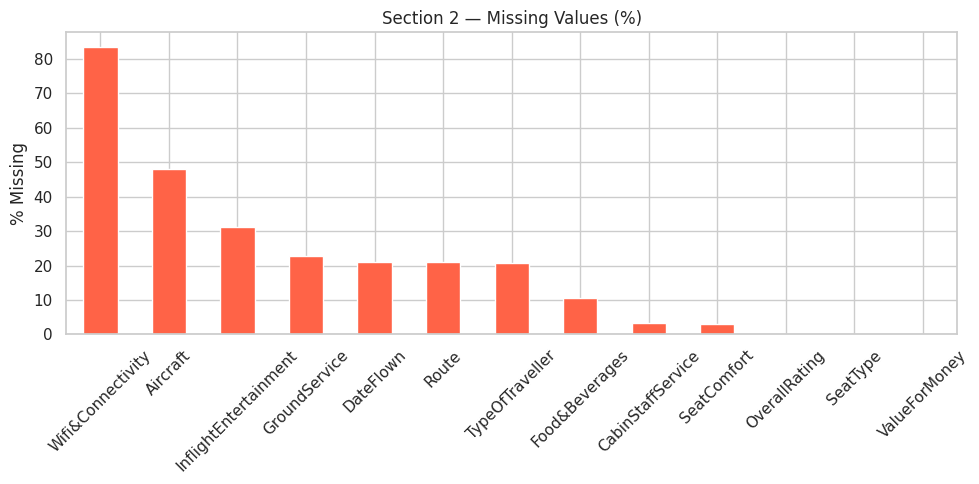

In [ ]:
missing = df2_raw.isnull().sum()
missing_pct = (missing / len(df2_raw) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})

missing_df = missing_df[missing_df['missing_count'] > 0] \
    .sort_values('missing_pct', ascending=False)

print(missing_df)

if not missing_df.empty:
    missing_df['missing_pct'].plot(kind='bar', figsize=(10,5), color='tomato')
    plt.title('Section 2 — Missing Values (%)')
    plt.ylabel('% Missing')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values 🎉")

Recommended
no     2203
yes    1498
Name: count, dtype: int64


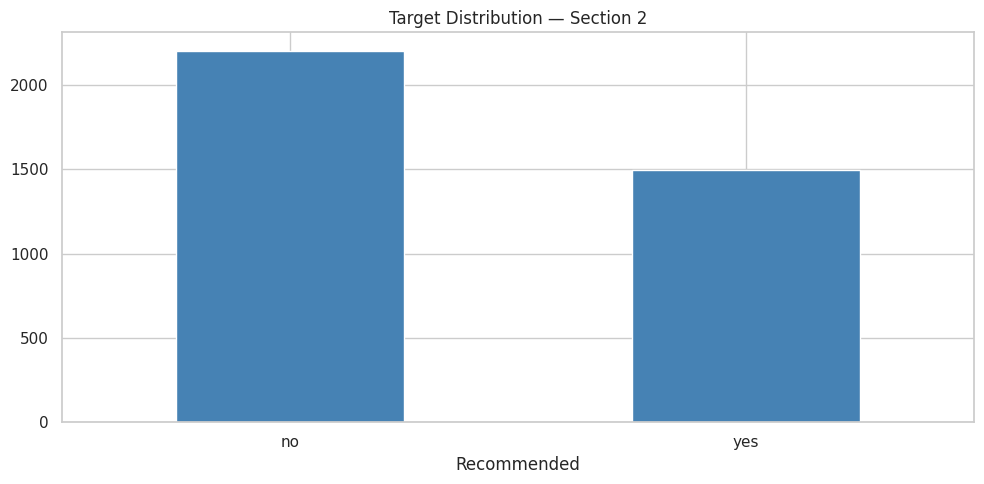

In [ ]:
target_col = 'Recommended'

if target_col in df2_raw.columns:
    print(df2_raw[target_col].value_counts())

    df2_raw[target_col].value_counts().plot(
        kind='bar',
        color='steelblue'
    )

    plt.title('Target Distribution — Section 2')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Target column not found")

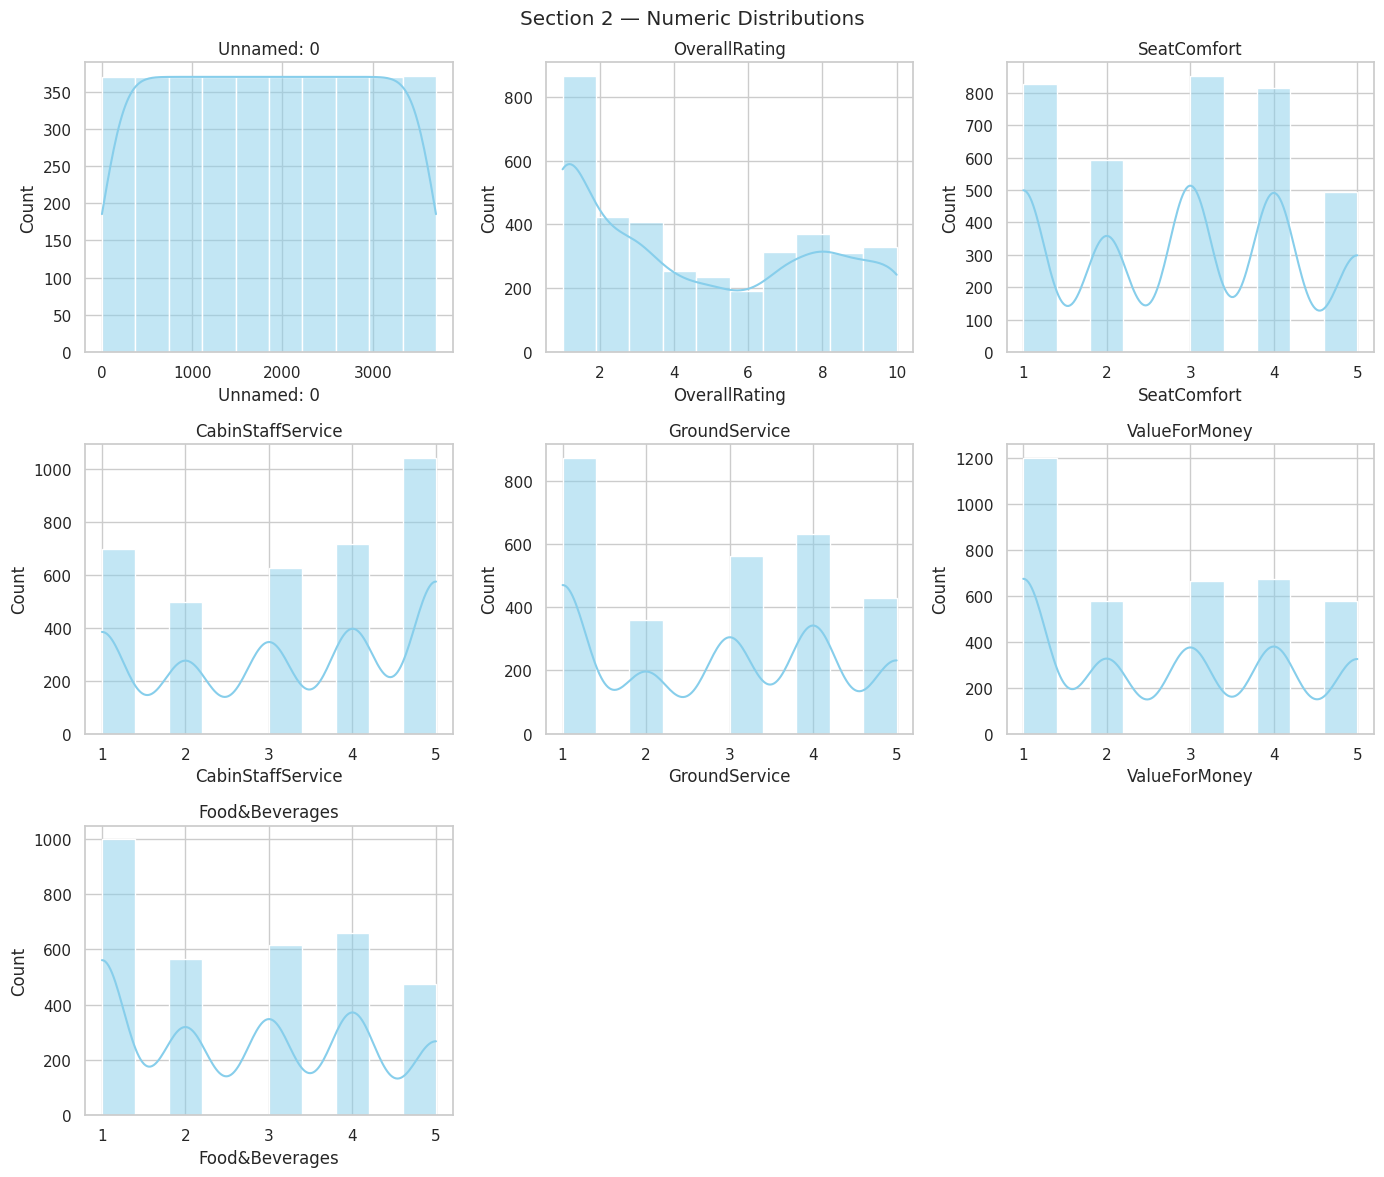

In [ ]:
rating_cols = df2_raw.select_dtypes(include=['int64','float64']).columns

rating_cols = [c for c in rating_cols if c != target_col]

rating_cols = rating_cols[:7]

if len(rating_cols) > 0:
    fig, axes = plt.subplots(3, 3, figsize=(14, 12))
    axes = axes.flatten()

    for i, col in enumerate(rating_cols):
        sns.histplot(df2_raw[col].dropna(), bins=10,
                     kde=True, ax=axes[i], color='skyblue')
        axes[i].set_title(col)


    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Section 2 — Numeric Distributions")
    plt.tight_layout()
    plt.show()
else:
    print("No numeric rating columns found")

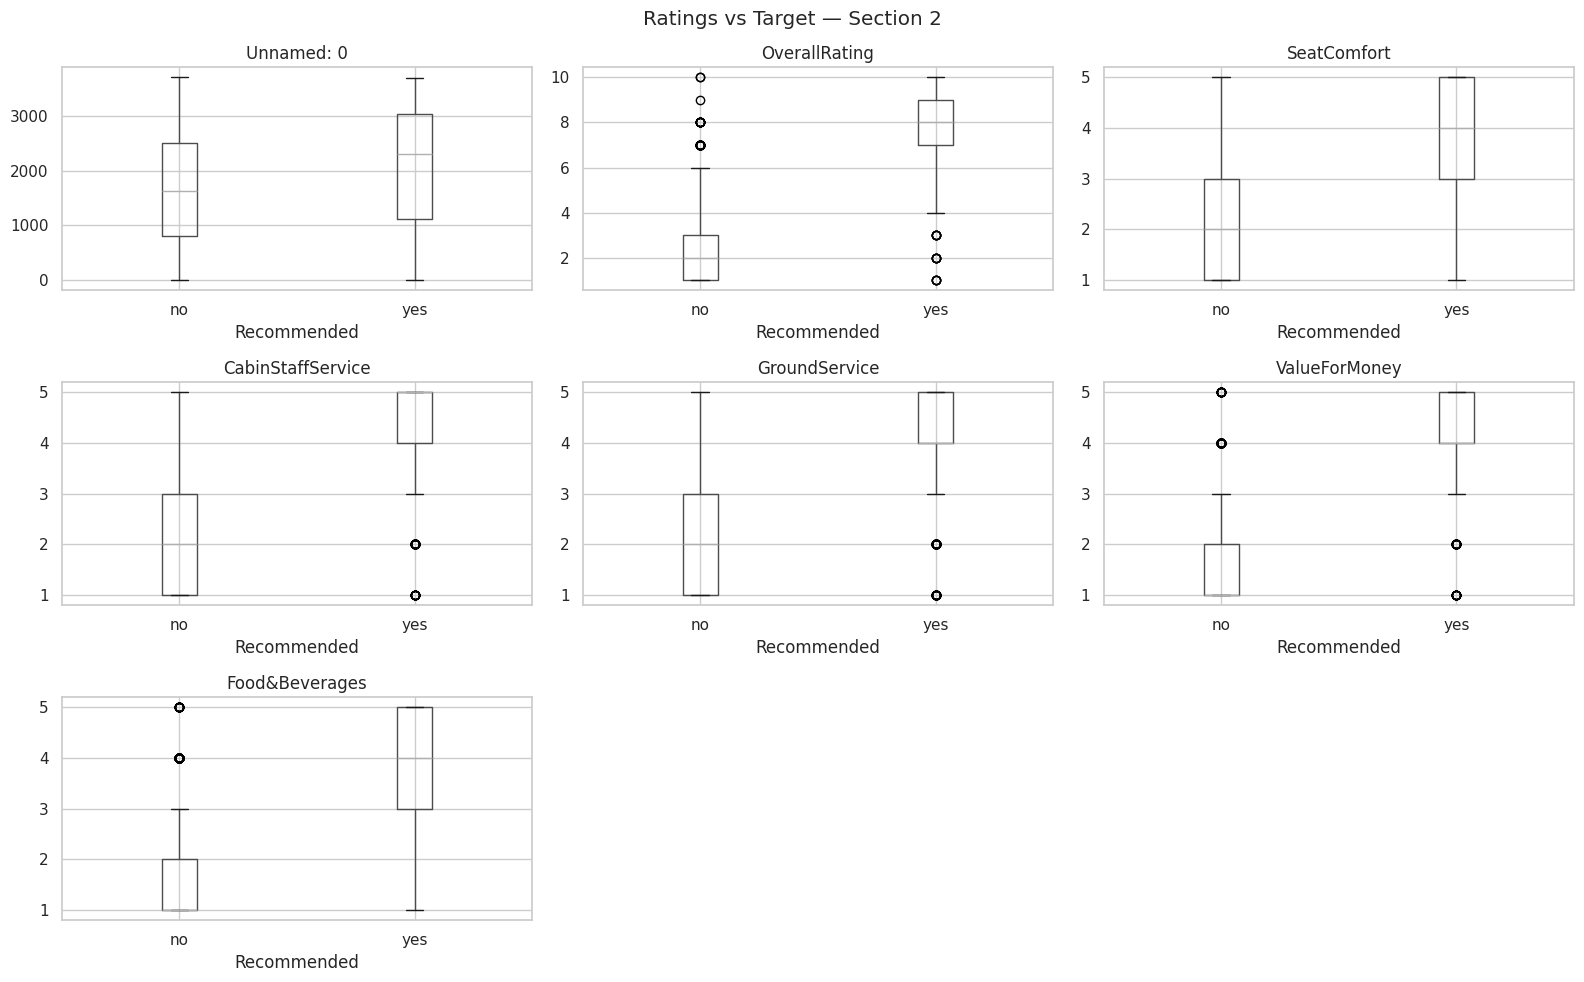

In [ ]:
if target_col in df2_raw.columns and len(rating_cols) > 0:

    fig, axes = plt.subplots(3, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, col in enumerate(rating_cols):
        df2_raw.boxplot(column=col, by=target_col, ax=axes[i])
        axes[i].set_title(col)

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Ratings vs Target — Section 2')
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot ratings vs target")

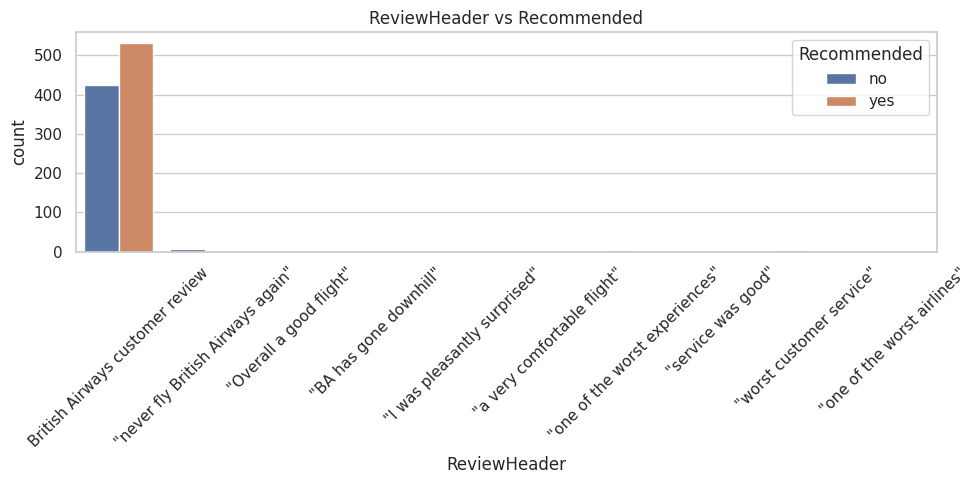

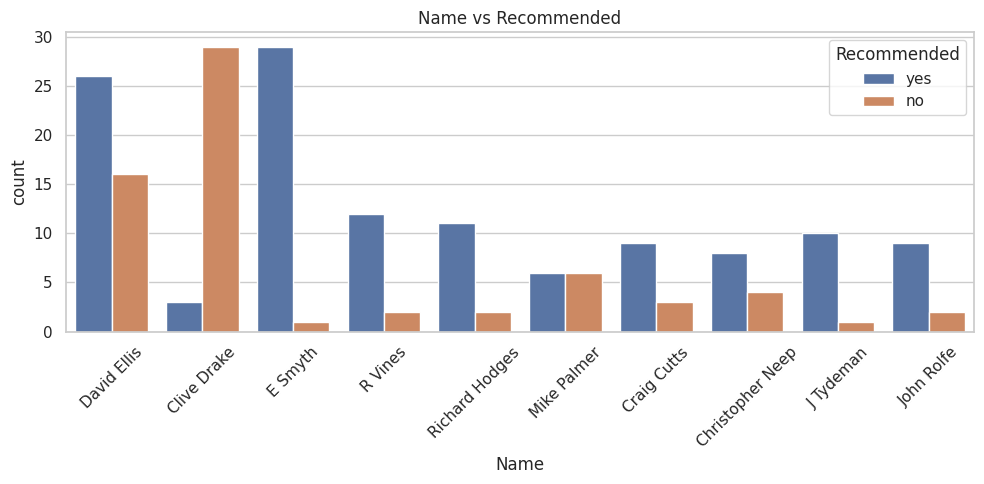

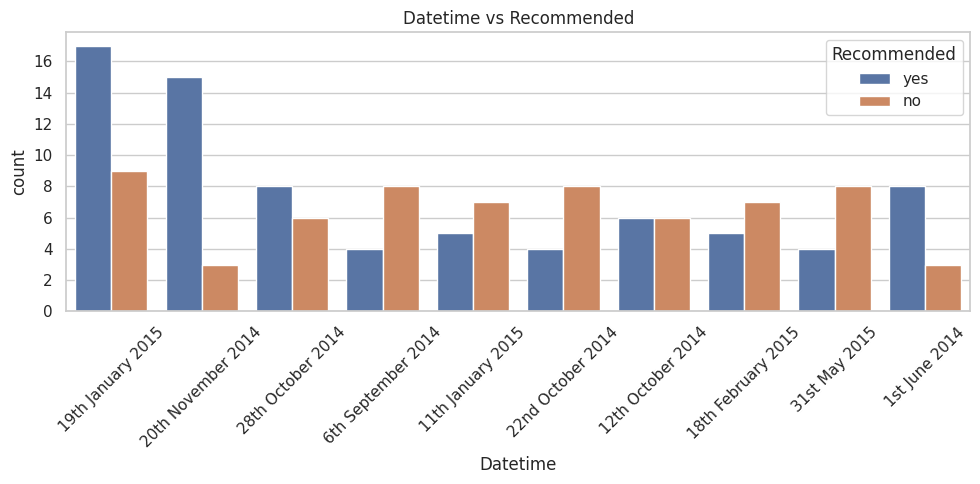

In [ ]:
cat_cols = df2_raw.select_dtypes(include='object').columns

for col in cat_cols[:3]:
    if col != target_col:

        temp = df2_raw[[col, target_col]].dropna()

        top = temp[col].value_counts().nlargest(10).index
        temp = temp[temp[col].isin(top)]

        plt.figure(figsize=(10,5))
        sns.countplot(x=col, hue=target_col, data=temp, order=top)

        plt.title(f'{col} vs {target_col}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

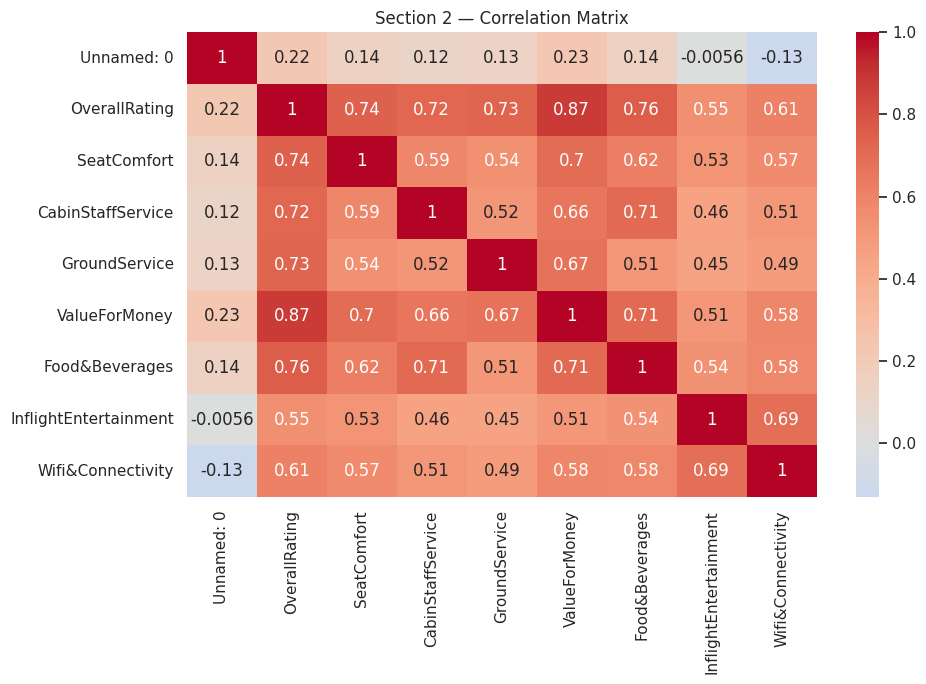

In [ ]:
df_corr = df2_raw.copy()

numeric_cols = df_corr.select_dtypes(include=['int64','float64']).columns

if len(numeric_cols) > 1:
    corr = df_corr[numeric_cols].corr()

    plt.figure(figsize=(10,7))
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
    plt.title("Section 2 — Correlation Matrix")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation")

## **Data Cleaning**

In [ ]:
df2_clean = df2_raw.copy()

df2_clean = df2_clean.rename(columns={
    'ReviewBody'            : 'Review',
    'VerifiedReview'        : 'Verified',
    'TypeOfTraveller'       : 'Type Of Traveller',
    'SeatType'              : 'Seat Type',
    'SeatComfort'           : 'Seat Comfort',
    'CabinStaffService'     : 'Cabin Staff Service',
    'Food&Beverages'        : 'Food & Beverages',
    'InflightEntertainment' : 'Inflight Entertainment',
    'GroundService'         : 'Ground Service',
    'Wifi&Connectivity'     : 'Wifi & Connectivity',
    'ValueForMoney'         : 'Value For Money',
})

drop2 = ['Unnamed: 0', 'ReviewHeader', 'Name', 'Datetime',
         'Route', 'DateFlown', 'Aircraft', 'Recommended',
         'OverallRating', 'Inflight Entertainment',
         'Wifi & Connectivity', 'Ground Service',
         'Type Of Traveller']
df2_clean = df2_clean.drop(columns=drop2, errors='ignore')

df2_clean = df2_clean.drop_duplicates()
df2_clean = df2_clean.drop_duplicates(subset='Review', keep='first')
print("After duplicates:", df2_clean.shape)

rating_cols2_clean = ['Seat Comfort', 'Cabin Staff Service',
                      'Food & Beverages', 'Value For Money']

for col in rating_cols2_clean:
    if col in df2_clean.columns:
        df2_clean[col] = pd.to_numeric(df2_clean[col],
                                       errors='coerce')
        df2_clean[col] = df2_clean[col].fillna(
            df2_clean[col].median())

df2_clean['avg_rating'] = df2_clean[rating_cols2_clean].mean(axis=1)
df2_clean['sentiment']  = df2_clean['avg_rating'].apply(
    rating_to_sentiment)
df2_clean = df2_clean.dropna(subset=['Review', 'sentiment'])
df2_clean = df2_clean.drop(columns=['avg_rating'])

print("\nMissing after cleaning:")
print(df2_clean.isnull().sum())
print("\nFinal shape:", df2_clean.shape)

print("\nSentiment Distribution:")
print(df2_clean['sentiment'].value_counts())
print(df2_clean['sentiment'].value_counts(normalize=True).round(3)*100)

After duplicates: (3692, 7)

Missing after cleaning:
Verified               0
Review                 0
Seat Type              2
Seat Comfort           0
Cabin Staff Service    0
Value For Money        0
Food & Beverages       0
sentiment              0
dtype: int64

Final shape: (3692, 8)

Sentiment Distribution:
sentiment
Negative    1439
Neutral     1265
Positive     988
Name: count, dtype: int64
sentiment
Negative    39.0
Neutral     34.3
Positive    26.8
Name: proportion, dtype: float64


## **Feature Selection**

=== Feature Importance Scores — Section 2 ===
            feature       score
    Value For Money 3836.482383
Cabin Staff Service 3445.824946
   Food & Beverages 3366.319996
       Seat Comfort 2828.349509


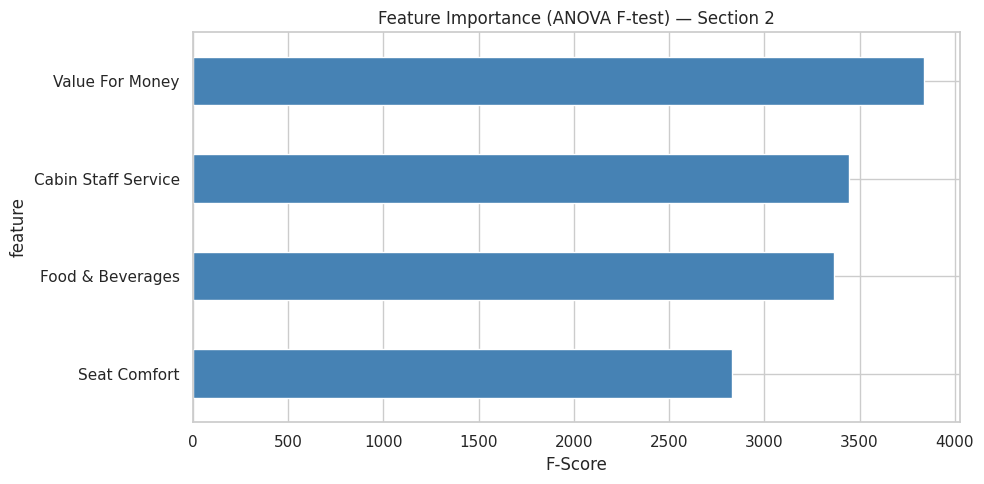

In [ ]:
X2_fs    = df2_clean[rating_cols2_clean].fillna(0)
le2_temp = LabelEncoder()
y2_fs    = le2_temp.fit_transform(df2_clean['sentiment'])

selector2 = SelectKBest(score_func=f_classif, k='all')
selector2.fit(X2_fs, y2_fs)

feature_scores2 = pd.DataFrame({
    'feature': rating_cols2_clean,
    'score'  : selector2.scores_
}).sort_values('score', ascending=False)

print("=== Feature Importance Scores — Section 2 ===")
print(feature_scores2.to_string(index=False))

feature_scores2.set_index('feature')['score'].plot(
    kind='barh', color='steelblue')
plt.title('Feature Importance (ANOVA F-test) — Section 2')
plt.xlabel('F-Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## **Data Preprocessing & NLP Pipeline**

In [ ]:
print("Applying NLP preprocessing to Section 2...")
df2_clean['Review_cleaned'] = df2_clean['Review'].apply(
    preprocess_text)

print("\n=== Before vs After ===")
for i in range(3):
    print(f"BEFORE: {df2_clean['Review'].iloc[i][:100]}")
    print(f"AFTER : {df2_clean['Review_cleaned'].iloc[i][:100]}")
    print()
print("Done! Shape:", df2_clean.shape)

Applying NLP preprocessing to Section 2...

=== Before vs After ===
BEFORE: 4 Hours before takeoff we received a Mail stating a cryptic message that there are disruptions to be
AFTER : hour takeoff received mail stating cryptic message disruption expected limit many plane leave time c

BEFORE: I recently had a delay on British Airways from BRU to LHR that was due to staff shortages. They anno
AFTER : recently delay british airway bru lhr due staff shortage announced hour holding delay would board u 

BEFORE: Boarded on time, but it took ages to get to the runway due to congestion. Flight was smooth and quic
AFTER : boarded time took age get runway due congestion flight smooth quick snack drink good short flight la

Done! Shape: (3692, 9)


## **Feature Engineering**

In [ ]:
df2_clean['review_length']       = df2_clean['Review'].apply(len)
df2_clean['word_count']          = df2_clean['Review'].apply(
    lambda x: len(x.split()))
df2_clean['overall_rating_mean'] = df2_clean[
    rating_cols2_clean].mean(axis=1)
df2_clean['rating_std']          = df2_clean[
    rating_cols2_clean].std(axis=1)

print("Feature Engineering done! Shape:", df2_clean.shape)

Feature Engineering done! Shape: (3692, 13)


## **Train models**

In [ ]:
le2 = LabelEncoder()
y2  = le2.fit_transform(df2_clean['sentiment'])
print("Classes:", le2.classes_)

X2_train_text, X2_test_text, y2_train, y2_test = train_test_split(
    df2_clean['Review_cleaned'].astype(str), y2,
    test_size=0.2, random_state=42, stratify=y2
)

tfidf2 = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),
    stop_words=None,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X2_train_final = tfidf2.fit_transform(X2_train_text)
X2_test_final  = tfidf2.transform(X2_test_text)

print(f"Train size: {len(y2_train)}")
print(f"Test size : {len(y2_test)}")
print("Train shape:", X2_train_final.shape)
print("Test shape :", X2_test_final.shape)

Classes: ['Negative' 'Neutral' 'Positive']
Train size: 2953
Test size : 739
Train shape: (2953, 1000)
Test shape : (739, 1000)


In [ ]:
models2 = {
    'Logistic Regression' : LogisticRegression(max_iter=1000,
                                               C=1.0,
                                               random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=10,
                                                   random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100,
                                                   max_depth=15,
                                                   random_state=42),
    'Naive Bayes'         : MultinomialNB(),
    'SGD Classifier'      : SGDClassifier(max_iter=1000,
                                          random_state=42),
}

results2 = []

for name, model in models2.items():
    print(f"Training: {name}...")
    model.fit(X2_train_final, y2_train)
    y2_pred = model.predict(X2_test_final)

    results2.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y2_test, y2_pred),
        'Precision': precision_score(y2_test, y2_pred,
                                    average='weighted',
                                    zero_division=0),
        'Recall'   : recall_score(y2_test, y2_pred,
                                 average='weighted',
                                 zero_division=0),
        'F1'       : f1_score(y2_test, y2_pred,
                             average='weighted',
                             zero_division=0),
    })
    print(f"  ✅ F1: {results2[-1]['F1']:.4f}")

print("\nAll Section 2 models trained!")

Training: Logistic Regression...
  ✅ F1: 0.6437
Training: Decision Tree...
  ✅ F1: 0.5247
Training: Random Forest...
  ✅ F1: 0.5852
Training: Naive Bayes...
  ✅ F1: 0.5963
Training: SGD Classifier...
  ✅ F1: 0.6192

All Section 2 models trained!


## **Evaluation**

=== Section 2 — British Airways Results ===
                     Accuracy  Precision  Recall      F1
Model                                                   
Logistic Regression    0.6509     0.6429  0.6509  0.6437
SGD Classifier         0.6225     0.6172  0.6225  0.6192
Naive Bayes            0.6279     0.6022  0.6279  0.5963
Random Forest          0.6238     0.6054  0.6238  0.5852
Decision Tree          0.5467     0.5322  0.5467  0.5247


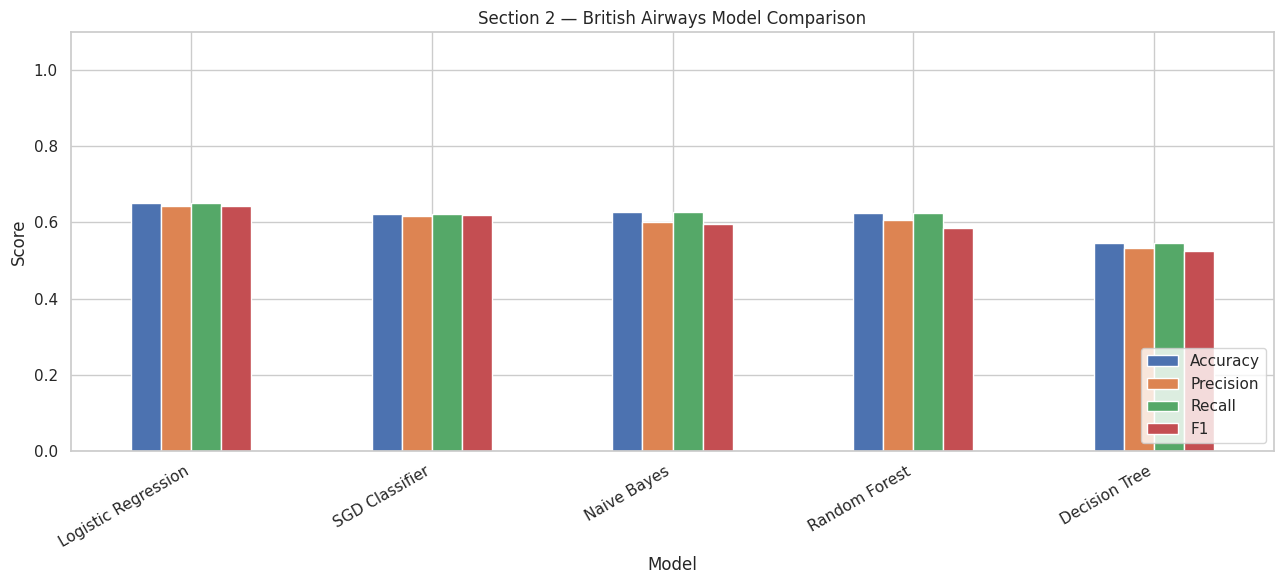

In [ ]:
results2_df = pd.DataFrame(results2).set_index('Model')
results2_df = results2_df.sort_values('F1',
                                      ascending=False).round(4)

print("=== Section 2 — British Airways Results ===")
print(results2_df.to_string())

results2_df[['Accuracy','Precision','Recall','F1']].plot(
    kind='bar', figsize=(13, 6), ylim=(0, 1.1))
plt.title('Section 2 — British Airways Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
best2_name  = results2_df.index[0]
best2_model = models2[best2_name]
y2_pred_best = best2_model.predict(X2_test_final)

print(f"Best Model: {best2_name}\n")
print(classification_report(y2_test, y2_pred_best,
                            target_names=le2.classes_))

Best Model: Logistic Regression

              precision    recall  f1-score   support

    Negative       0.68      0.80      0.73       288
     Neutral       0.52      0.44      0.48       253
    Positive       0.74      0.71      0.72       198

    accuracy                           0.65       739
   macro avg       0.65      0.65      0.65       739
weighted avg       0.64      0.65      0.64       739



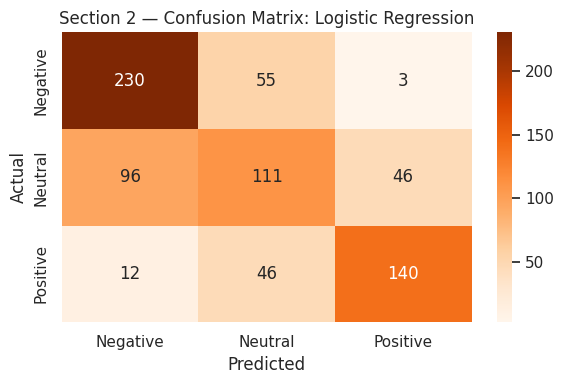

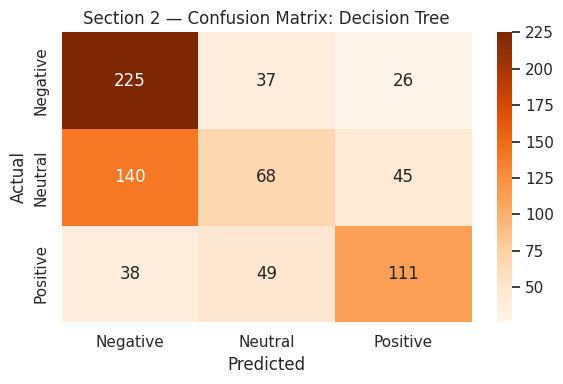

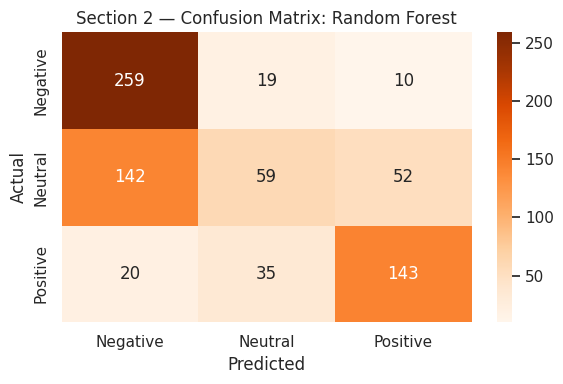

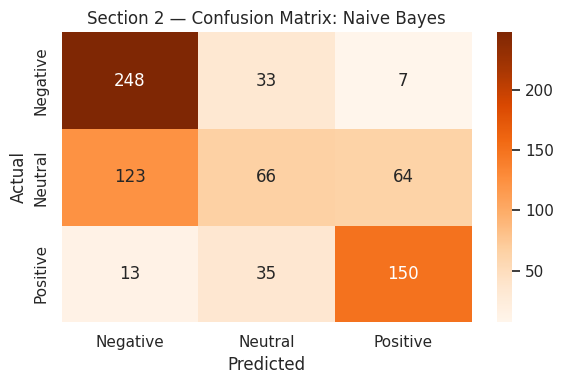

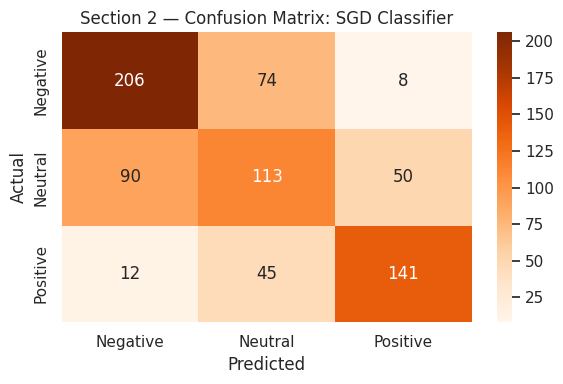

In [ ]:
for name, model in models2.items():
    y_pred = model.predict(X2_test_final)
    cm = confusion_matrix(y2_test, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=le2.classes_,
                yticklabels=le2.classes_)
    plt.title(f'Section 2 — Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

# Section 3 — Global Airlines (Full Pipeline)

## load dataset

In [ ]:
DATASET_NAME3 = "rosemeenshaikh/global-airline-reviews"
FILE_PATH3    = "Airline_Reviews_Combined.xlsx"

df3_raw = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    DATASET_NAME3, FILE_PATH3
)

print("Shape:", df3_raw.shape)
print("Columns:", df3_raw.columns.tolist())
df3_raw.head()

Using Colab cache for faster access to the 'global-airline-reviews' dataset.
Shape: (7730, 20)
Columns: ['NAMES', 'Title', 'Author', 'Country', 'Date', 'Verified', 'Review', 'Type Of Traveller', 'Seat Type', 'Route', 'Date Flown', 'Seat Comfort', 'Cabin Staff Service', 'Food & Beverages', 'Inflight Entertainment', 'Ground Service', 'Wifi & Connectivity', 'Value For Money', 'Recommended', 'Aircraft']


,NAMES,Title,Author,Country,Date,Verified,Review,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended,Aircraft
0,AB Aviation,"""pretty decent airline""",Tom Hansen,Netherlands,11th November 2019,True,✅Trip Verified| Moroni to Moheli. Turned out ...,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,NaN,4.0,NaN,3.0,yes,NaN
1,AB Aviation,"""Not a good airline""",Gyan Fernando,United Kingdom,25th June 2019,True,✅Trip Verified| Moroni to Anjouan. It is a ver...,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,NaN,1.0,NaN,2.0,no,E120
2,AB Aviation,"""flight was fortunately short""",Gyan Fernando,United Kingdom,25th June 2019,True,✅Trip Verified| Anjouan to Dzaoudzi. A very s...,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,NaN,1.0,NaN,2.0,no,Embraer E120
3,Adria Airways,"""I will never fly again with Adria""",D Praetextatus,Serbia,28th September 2019,False,Not Verified| Please do a favor yourself and ...,Solo Leisure,Economy Class,Frankfurt to Pristina,September 2019,1.0,1.0,NaN,NaN,1.0,NaN,1.0,no,NaN
4,Adria Airways,"""it ruined our last days of holidays""",D Meijer,Netherlands,24th September 2019,True,✅Trip Verified| Do not book a flight with this...,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no,NaN


## **EDA - Understand Dataset**

In [ ]:
print("=== SECTION 3: SHAPE ===")
print(df3_raw.shape)

print("\n=== SECTION 3: NUMERIC SUMMARY ===")
print(df3_raw.describe().round(2))

print("\n=== SECTION 3: CATEGORICAL SUMMARY ===")
print(df3_raw.describe(include='object'))

=== SECTION 3: SHAPE ===
(7730, 20)

=== SECTION 3: NUMERIC SUMMARY ===
       Seat Comfort  Cabin Staff Service  Food & Beverages  \
count       6501.00              6455.00           4785.00   
mean           2.58                 2.87              2.58   
std            1.47                 1.61              1.53   
min            0.00                 0.00              0.00   
25%            1.00                 1.00              1.00   
50%            2.00                 3.00              2.00   
75%            4.00                 4.00              4.00   
max            5.00                 5.00              5.00   

       Inflight Entertainment  Ground Service  Wifi & Connectivity  \
count                 3159.00         6600.00              2088.00   
mean                     2.05            2.36                 1.78   
std                      1.44            1.60                 1.35   
min                      0.00            1.00                 1.00   
25%                


=== SECTION 3: MISSING VALUES ===
                        missing_count  missing_pct
Wifi & Connectivity              5642        72.99
Aircraft                         4969        64.28
Inflight Entertainment           4571        59.13
Food & Beverages                 2945        38.10
Cabin Staff Service              1275        16.49
Seat Comfort                     1229        15.90
Ground Service                   1130        14.62
Route                             834        10.79
Date Flown                        804        10.40
Type Of Traveller                 800        10.35
Seat Type                         293         3.79
Value For Money                   281         3.64
Country                           253         3.27
Title                             120         1.55


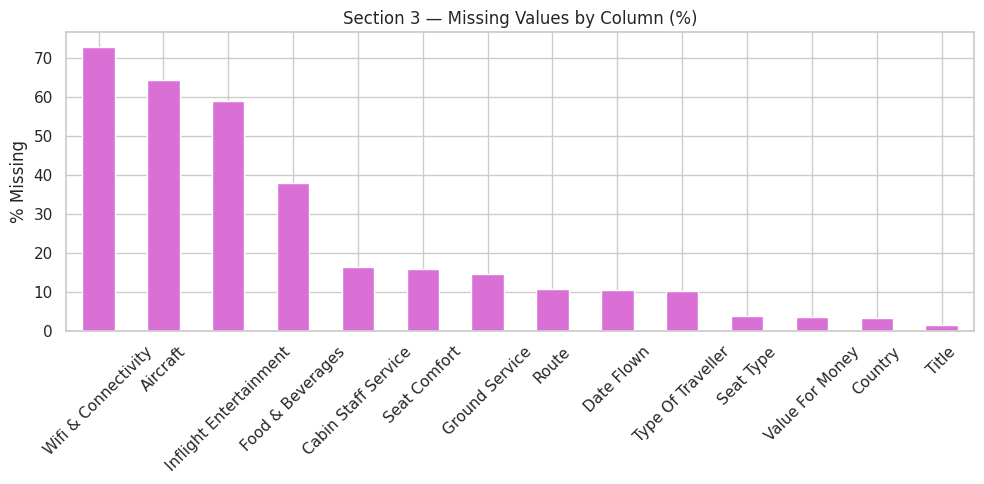

In [ ]:
missing3     = df3_raw.isnull().sum()
missing3_pct = (missing3 / len(df3_raw) * 100).round(2)
missing3_df  = pd.DataFrame({
    'missing_count': missing3,
    'missing_pct'  : missing3_pct
})
missing3_df = missing3_df[
    missing3_df['missing_count'] > 0
].sort_values('missing_pct', ascending=False)

print("\n=== SECTION 3: MISSING VALUES ===")
print(missing3_df)

if not missing3_df.empty:
    plt.figure(figsize=(10, 5))
    missing3_df['missing_pct'].plot(kind='bar', color='orchid')
    plt.title('Section 3 — Missing Values by Column (%)')
    plt.ylabel('% Missing')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


=== SECTION 3: Recommended Distribution ===
Recommended
no     5144
yes    2586
Name: count, dtype: int64
Recommended
no     66.5
yes    33.5
Name: proportion, dtype: float64


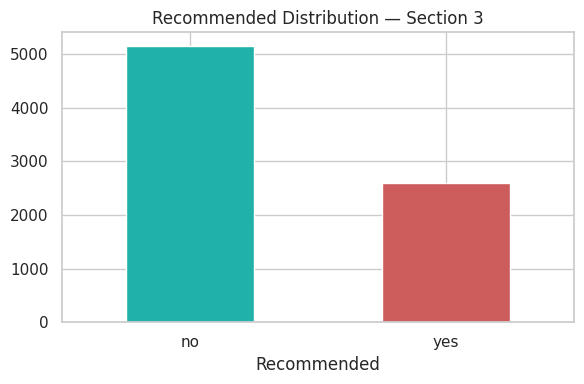

In [ ]:
print("\n=== SECTION 3: Recommended Distribution ===")
print(df3_raw['Recommended'].value_counts())
print(df3_raw['Recommended'].value_counts(normalize=True).round(3) * 100)

plt.figure(figsize=(6, 4))
df3_raw['Recommended'].value_counts().plot(
    kind='bar', color=['lightseagreen', 'indianred'])
plt.title('Recommended Distribution — Section 3')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

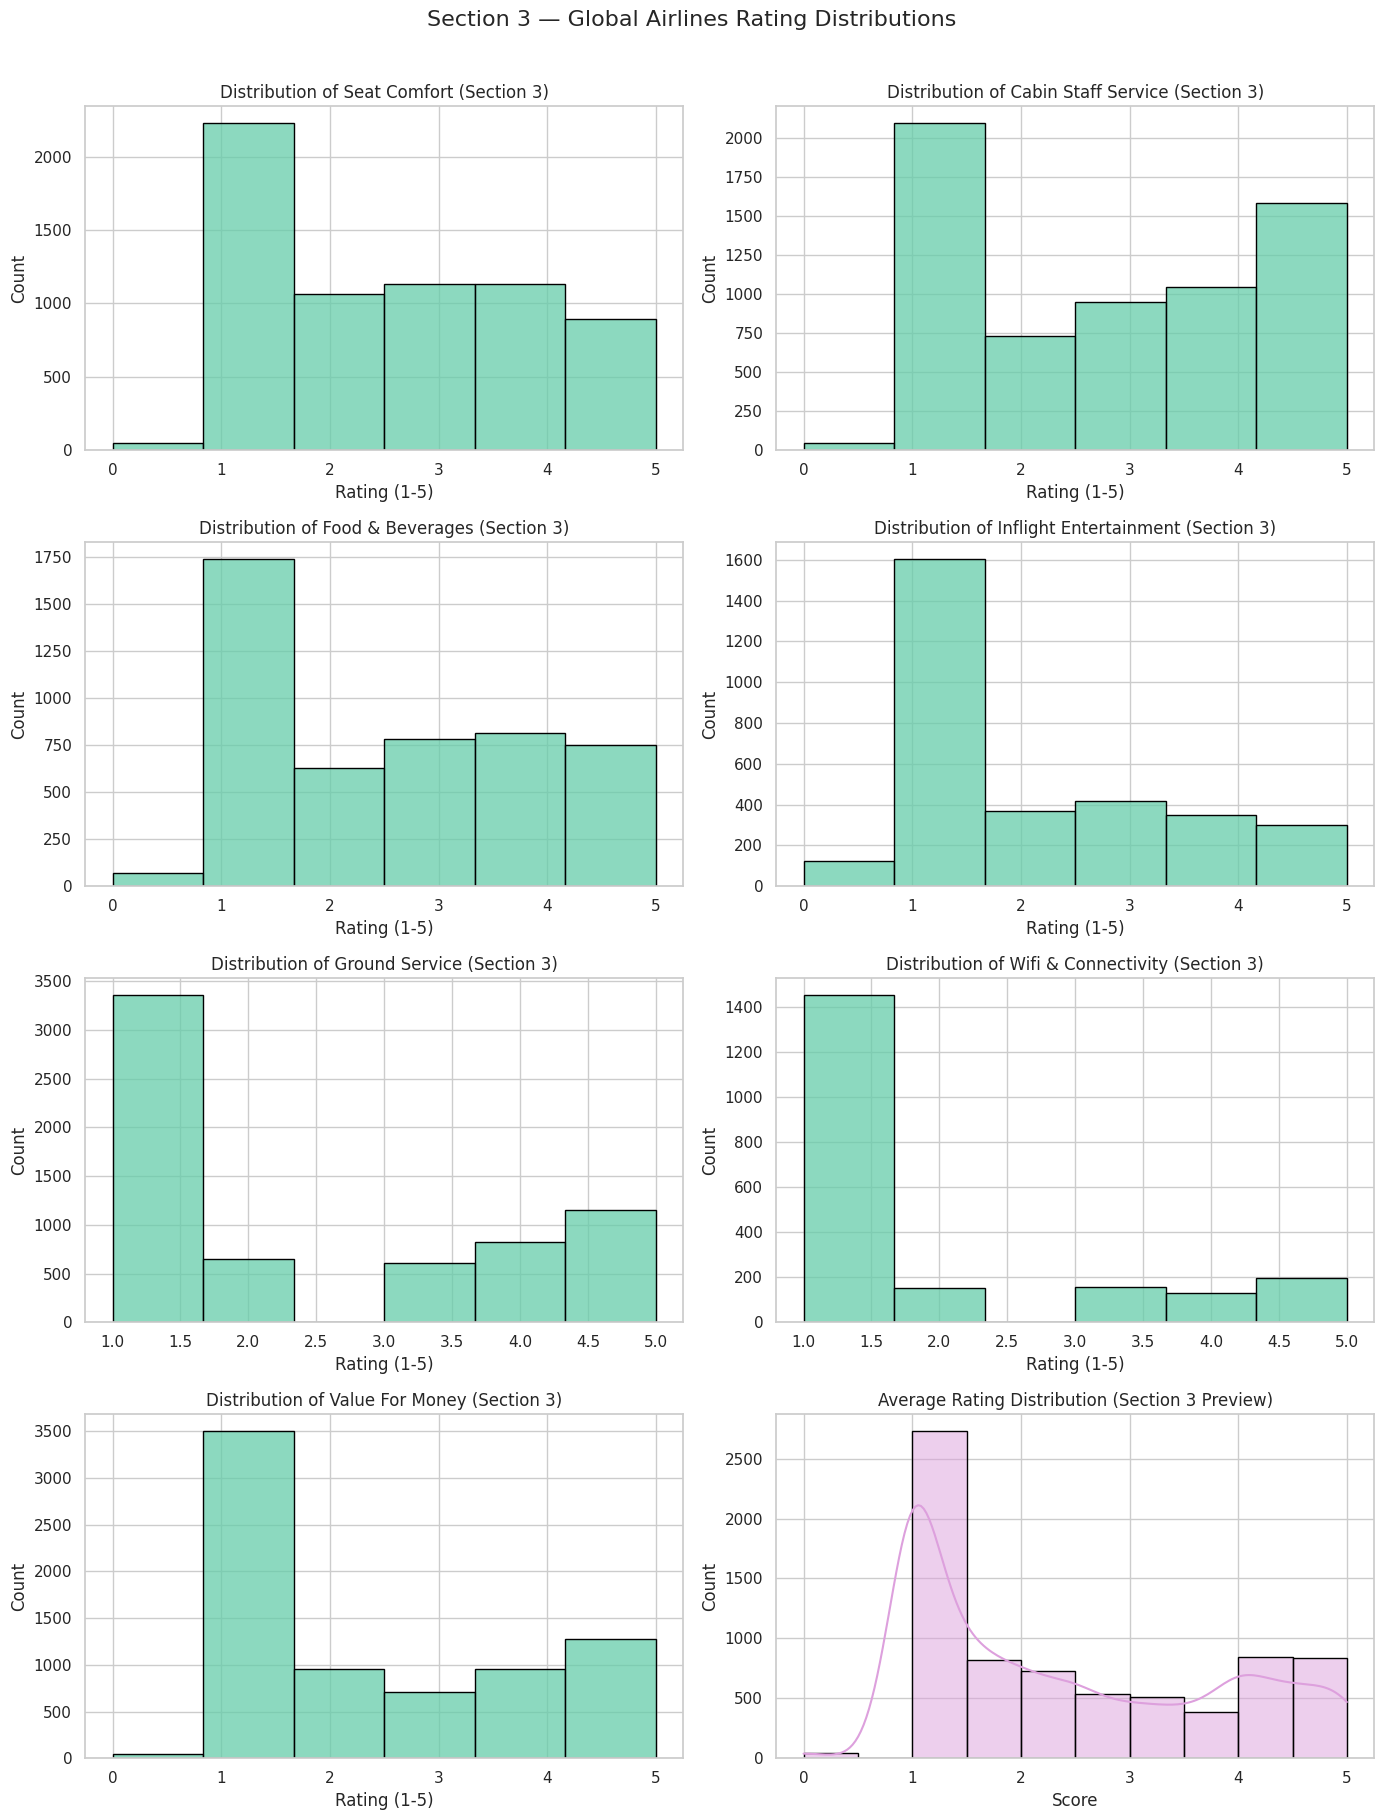

In [ ]:
rating_cols3 = ['Seat Comfort', 'Cabin Staff Service',
                'Food & Beverages', 'Inflight Entertainment',
                'Ground Service', 'Wifi & Connectivity',
                'Value For Money']

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(rating_cols3):
    sns.histplot(df3_raw[col].dropna(), bins=6, kde=False,
                 ax=axes[i], color='mediumaquamarine', edgecolor='black')
    axes[i].set_title(f'Distribution of {col} (Section 3)')
    axes[i].set_xlabel('Rating (1-5)')
    axes[i].set_ylabel('Count')

avg_preview3 = df3_raw[rating_cols3].mean(axis=1)
sns.histplot(avg_preview3.dropna(), bins=10, kde=True,
             ax=axes[7], color='plum', edgecolor='black')
axes[7].set_title('Average Rating Distribution (Section 3 Preview)')
axes[7].set_xlabel('Score')

plt.suptitle('Section 3 — Global Airlines Rating Distributions', y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

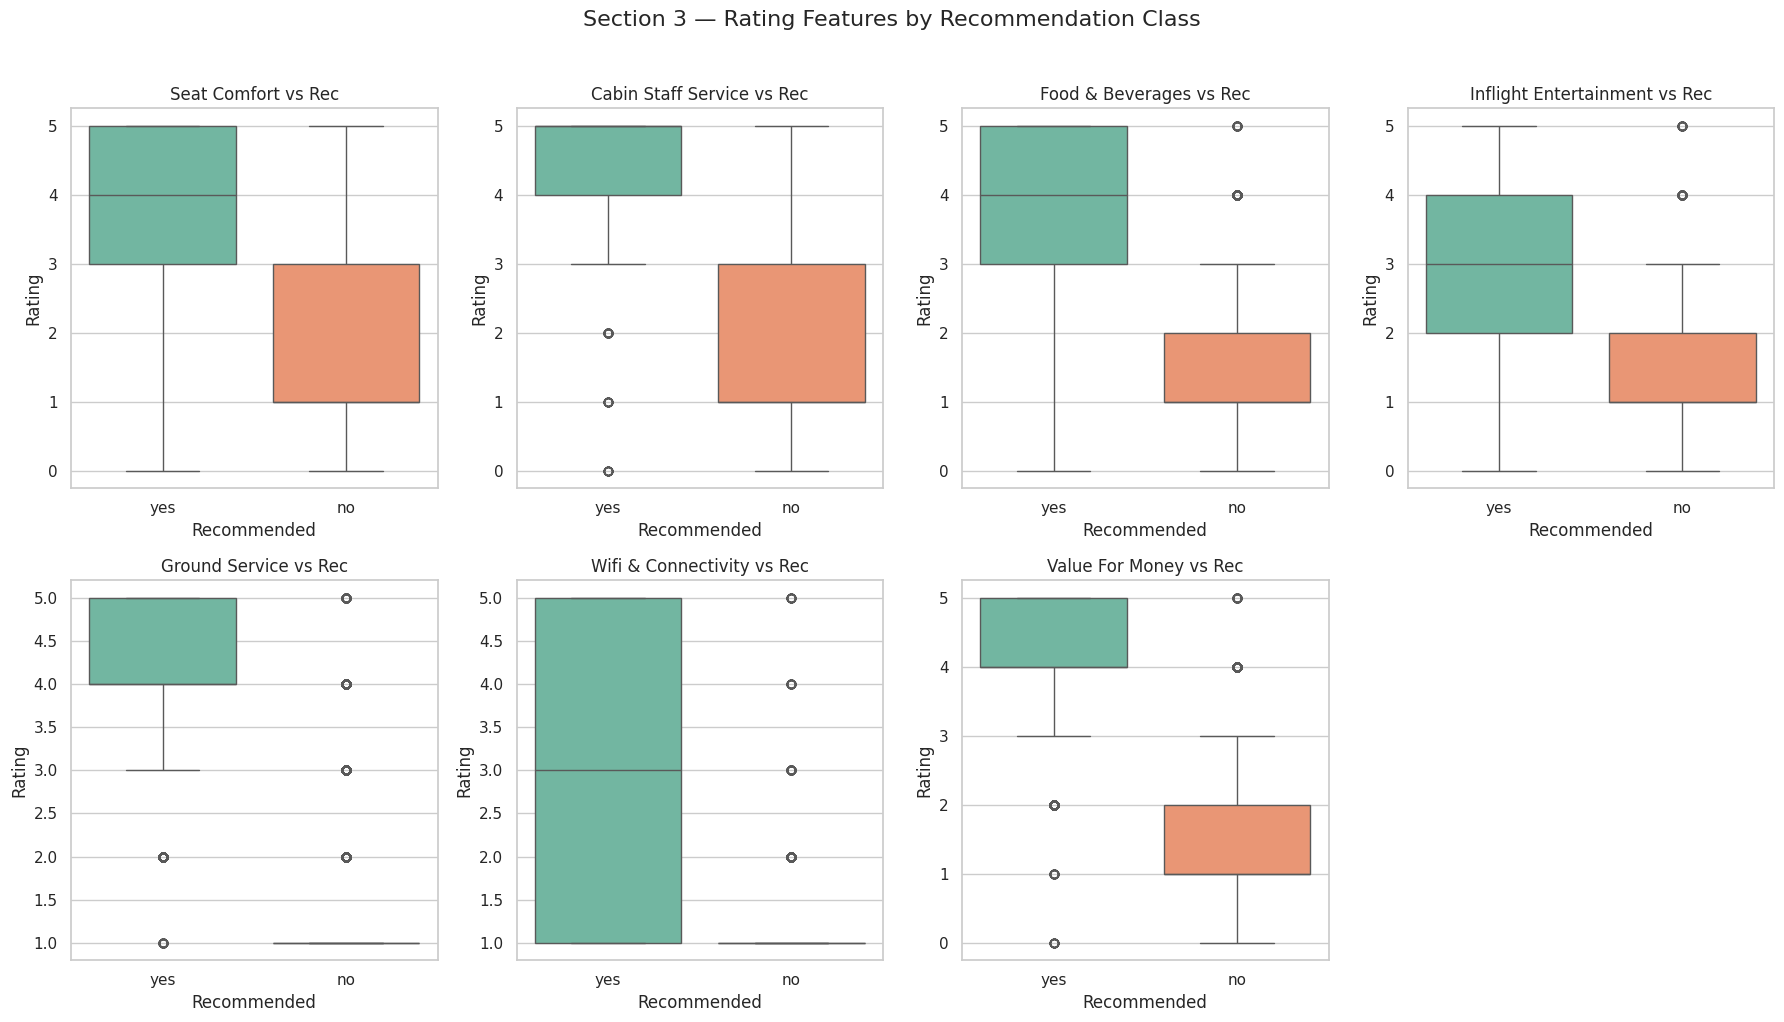

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(rating_cols3):
    sns.boxplot(x='Recommended', y=col, data=df3_raw, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Rec')
    axes[i].set_xlabel('Recommended')
    axes[i].set_ylabel('Rating')

axes[7].set_axis_off()

plt.suptitle('Section 3 — Rating Features by Recommendation Class', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

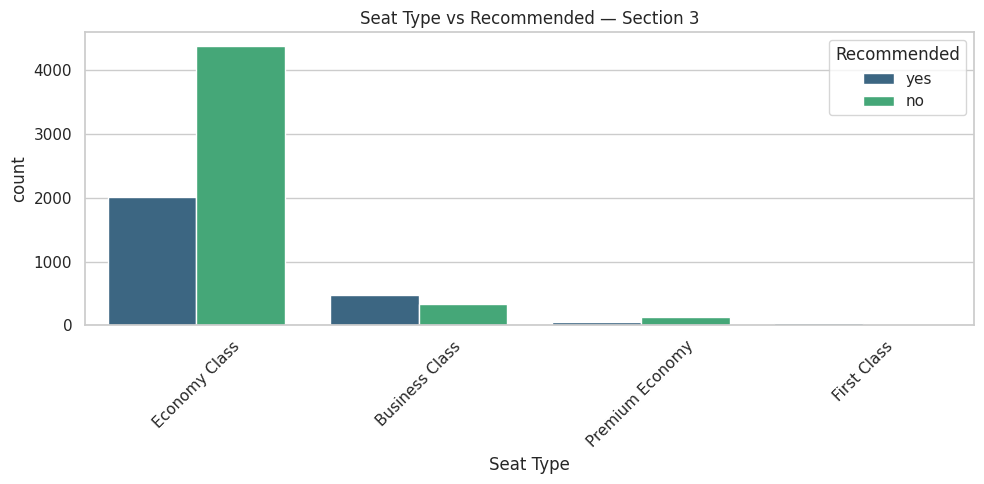

In [ ]:
if 'Seat Type' in df3_raw.columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(x='Seat Type', hue='Recommended', data=df3_raw, palette='viridis')
    plt.title('Seat Type vs Recommended — Section 3')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

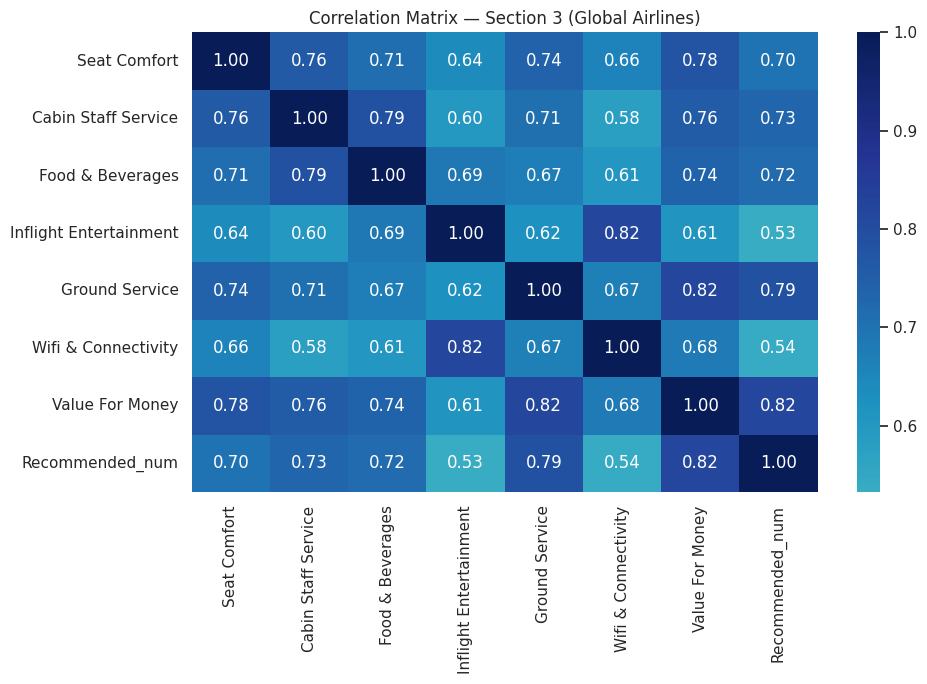

In [ ]:
df3_corr = df3_raw.copy()
df3_corr['Recommended_num'] = df3_corr['Recommended'].map(
    {'yes': 1, 'no': 0, 'Yes': 1, 'No': 0})

corr3 = df3_corr[rating_cols3 + ['Recommended_num']].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr3, annot=True, fmt='.2f',
            cmap='YlGnBu', center=0.5)
plt.title('Correlation Matrix — Section 3 (Global Airlines)')
plt.tight_layout()
plt.show()

## **Data Cleaning**

In [ ]:
df3_clean = df3_raw.copy()

df3_clean = df3_clean.drop_duplicates()
df3_clean = df3_clean.drop_duplicates(subset='Review', keep='first')
print("After duplicates:", df3_clean.shape)

df3_clean['Review'] = df3_clean['Review'].str.replace(
    r'^.*?\|', '', regex=True).str.strip()

drop3 = ['NAMES', 'Author', 'Title', 'Route', 'Date',
         'Date Flown', 'Aircraft', 'Recommended',
         'Type Of Traveller', 'Wifi & Connectivity',
         'Ground Service', 'Inflight Entertainment',
         'Food & Beverages']
df3_clean = df3_clean.drop(columns=drop3, errors='ignore')
print("After dropping columns:", df3_clean.shape)

rating_cols3_clean = ['Seat Comfort', 'Cabin Staff Service',
                      'Value For Money']

for col in rating_cols3_clean:
    if col in df3_clean.columns:
        df3_clean[col] = pd.to_numeric(df3_clean[col],
                                       errors='coerce')
        df3_clean[col] = df3_clean[col].fillna(
            df3_clean[col].median())

df3_clean['avg_rating'] = df3_clean[rating_cols3_clean].mean(axis=1)
df3_clean['sentiment']  = df3_clean['avg_rating'].apply(
    rating_to_sentiment)
df3_clean = df3_clean.dropna(subset=['Review', 'sentiment'])
df3_clean = df3_clean.drop(columns=['avg_rating'])

for col in ['Country', 'Seat Type']:
    if col in df3_clean.columns:
        df3_clean[col] = df3_clean[col].fillna(
            df3_clean[col].mode()[0])

print("\nMissing after cleaning:")
print(df3_clean.isnull().sum())
print("\nFinal shape:", df3_clean.shape)

print("\nSentiment Distribution:")
print(df3_clean['sentiment'].value_counts())
print(df3_clean['sentiment'].value_counts(normalize=True).round(3)*100)

After duplicates: (7299, 20)
After dropping columns: (7299, 7)

Missing after cleaning:
Country                0
Verified               0
Review                 0
Seat Type              0
Seat Comfort           0
Cabin Staff Service    0
Value For Money        0
sentiment              0
dtype: int64

Final shape: (7299, 8)

Sentiment Distribution:
sentiment
Negative    4248
Positive    1707
Neutral     1344
Name: count, dtype: int64
sentiment
Negative    58.2
Positive    23.4
Neutral     18.4
Name: proportion, dtype: float64


## **Feature Selection**

=== Feature Importance Scores — Section 3 ===
            feature        score
    Value For Money 15527.825079
       Seat Comfort  9057.413833
Cabin Staff Service  6681.245116


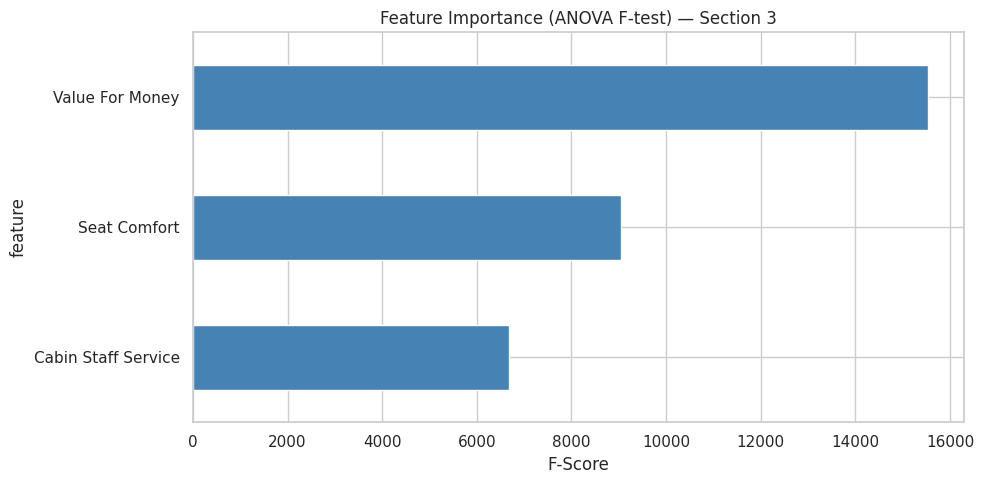

In [ ]:
X3_fs    = df3_clean[rating_cols3_clean].fillna(0)
le3_temp = LabelEncoder()
y3_fs    = le3_temp.fit_transform(df3_clean['sentiment'])

selector3 = SelectKBest(score_func=f_classif, k='all')
selector3.fit(X3_fs, y3_fs)

feature_scores3 = pd.DataFrame({
    'feature': rating_cols3_clean,
    'score'  : selector3.scores_
}).sort_values('score', ascending=False)

print("=== Feature Importance Scores — Section 3 ===")
print(feature_scores3.to_string(index=False))

feature_scores3.set_index('feature')['score'].plot(
    kind='barh', color='steelblue')
plt.title('Feature Importance (ANOVA F-test) — Section 3')
plt.xlabel('F-Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## **Data Preprocessing & NLP Pipeline**
## Text Preprocessing (NLP Pipeline)
### Steps applied:
1. **Lowercase conversion**: Uniformity for text matching.
2. **Clean-up**: Remove URLs, emails, and special characters.
3. **Tokenization**: Breaking text into individual words.
4. **Stopword removal**: Removing common words while preserving negations (e.g., 'not').
5. **Lemmatization**: Reducing words to their base root form.
6. **TF-IDF Vectorization**: Converting text to numeric vectors with unigrams and bigrams.

In [ ]:
print("Applying NLP preprocessing to Section 3...")
df3_clean['Review_cleaned'] = df3_clean['Review'].apply(
    preprocess_text)

print("\n=== Before vs After ===")
for i in range(3):
    print(f"BEFORE: {df3_clean['Review'].iloc[i][:100]}")
    print(f"AFTER : {df3_clean['Review_cleaned'].iloc[i][:100]}")
    print()
print("Done! Shape:", df3_clean.shape)

Applying NLP preprocessing to Section 3...

=== Before vs After ===
BEFORE: Moroni to Moheli. Turned out to be a pretty decent airline. Online booking worked well, checkin and 
AFTER : moroni moheli turned pretty decent airline online booking worked well checkin boarding fine plane lo

BEFORE: Moroni to Anjouan. It is a very small airline. My ticket advised me to turn up at 0800hrs which I di
AFTER : moroni anjouan small airline ticket advised turn hr confusion small airport directed office ab aviat

BEFORE: Anjouan to Dzaoudzi. A very small airline and the only airline based in Comoros. Check-in was disorg
AFTER : anjouan dzaoudzi small airline airline based comoros checkin disorganised local big package disinter

Done! Shape: (7299, 9)


## **Feature Engineering**


In [ ]:
df3_clean['review_length']       = df3_clean['Review'].apply(len)
df3_clean['word_count']          = df3_clean['Review'].apply(
    lambda x: len(x.split()))
df3_clean['overall_rating_mean'] = df3_clean[
    rating_cols3_clean].mean(axis=1)
df3_clean['rating_std']          = df3_clean[
    rating_cols3_clean].std(axis=1)

print("Feature Engineering done! Shape:", df3_clean.shape)

Feature Engineering done! Shape: (7299, 13)


## Train models

In [ ]:
le3 = LabelEncoder()
y3  = le3.fit_transform(df3_clean['sentiment'])
print("Classes:", le3.classes_)

X3_train_text, X3_test_text, y3_train, y3_test = train_test_split(
    df3_clean['Review_cleaned'].astype(str), y3,
    test_size=0.2, random_state=42, stratify=y3
)

tfidf3 = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),
    stop_words=None,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X3_train_final = tfidf3.fit_transform(X3_train_text)
X3_test_final  = tfidf3.transform(X3_test_text)

print(f"Train size: {len(y3_train)}")
print(f"Test size : {len(y3_test)}")
print("Train shape:", X3_train_final.shape)
print("Test shape :", X3_test_final.shape)

Classes: ['Negative' 'Neutral' 'Positive']
Train size: 5839
Test size : 1460
Train shape: (5839, 1000)
Test shape : (1460, 1000)


In [ ]:
models3 = {
    'Logistic Regression' : LogisticRegression(max_iter=1000,
                                               C=1.0,
                                               random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=10,
                                                   random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100,
                                                   max_depth=15,
                                                   random_state=42),
    'Naive Bayes'         : MultinomialNB(),
    'SGD Classifier'      : SGDClassifier(max_iter=1000,
                                          random_state=42),
}

results3 = []

for name, model in models3.items():
    print(f"Training: {name}...")
    model.fit(X3_train_final, y3_train)
    y3_pred = model.predict(X3_test_final)

    results3.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y3_test, y3_pred),
        'Precision': precision_score(y3_test, y3_pred,
                                    average='weighted',
                                    zero_division=0),
        'Recall'   : recall_score(y3_test, y3_pred,
                                 average='weighted',
                                 zero_division=0),
        'F1'       : f1_score(y3_test, y3_pred,
                             average='weighted',
                             zero_division=0),
    })
    print(f"  ✅ F1: {results3[-1]['F1']:.4f}")

print("\nAll Section 3 models trained!")

Training: Logistic Regression...
  ✅ F1: 0.7189
Training: Decision Tree...
  ✅ F1: 0.6678
Training: Random Forest...
  ✅ F1: 0.6545
Training: Naive Bayes...
  ✅ F1: 0.6828
Training: SGD Classifier...
  ✅ F1: 0.7043

All Section 3 models trained!


## Evaluation

=== Section 3 — Global Airlines Results ===
                     Accuracy  Precision  Recall      F1
Model                                                   
Logistic Regression    0.7527     0.7132  0.7527  0.7189
SGD Classifier         0.7534     0.7027  0.7534  0.7043
Naive Bayes            0.7397     0.6956  0.7397  0.6828
Decision Tree          0.7007     0.6567  0.7007  0.6678
Random Forest          0.7308     0.5946  0.7308  0.6545


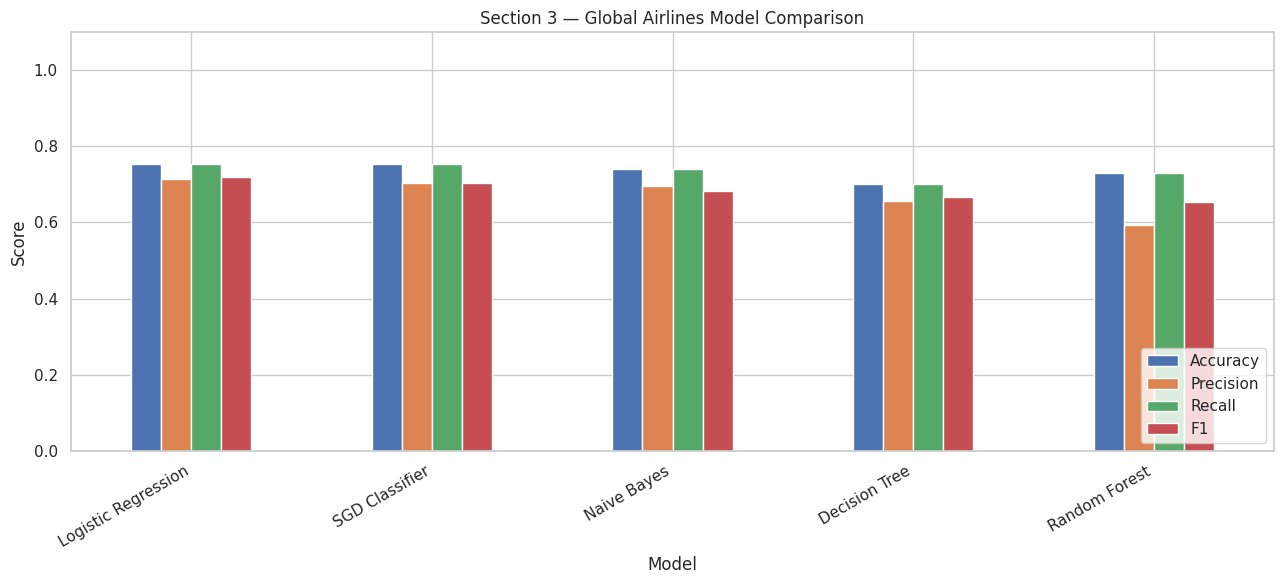

In [ ]:
results3_df = pd.DataFrame(results3).set_index('Model')
results3_df = results3_df.sort_values('F1',
                                      ascending=False).round(4)

print("=== Section 3 — Global Airlines Results ===")
print(results3_df.to_string())

results3_df[['Accuracy','Precision','Recall','F1']].plot(
    kind='bar', figsize=(13, 6), ylim=(0, 1.1))
plt.title('Section 3 — Global Airlines Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
best3_name  = results3_df.index[0]
best3_model = models3[best3_name]
y3_pred_best = best3_model.predict(X3_test_final)

print(f"Best Model: {best3_name}\n")
print(classification_report(y3_test, y3_pred_best,
                            target_names=le3.classes_))

Best Model: Logistic Regression

              precision    recall  f1-score   support

    Negative       0.80      0.94      0.86       850
     Neutral       0.44      0.17      0.25       269
    Positive       0.71      0.75      0.73       341

    accuracy                           0.75      1460
   macro avg       0.65      0.62      0.61      1460
weighted avg       0.71      0.75      0.72      1460



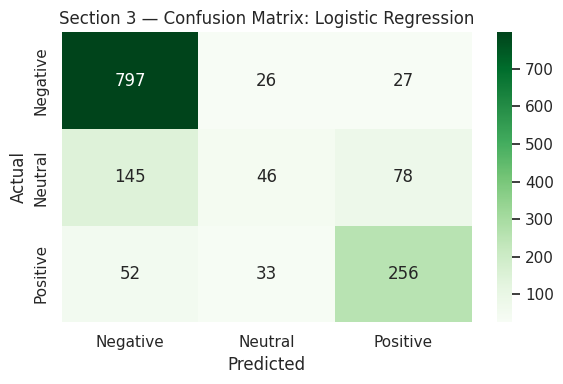

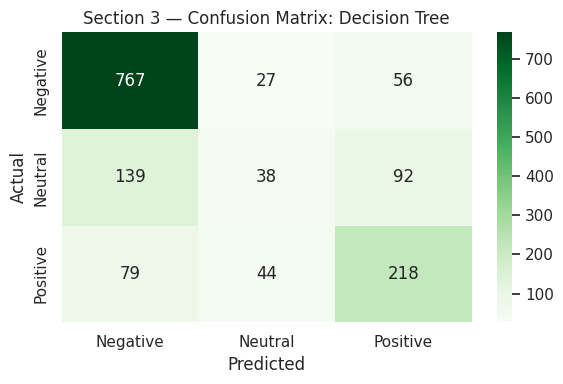

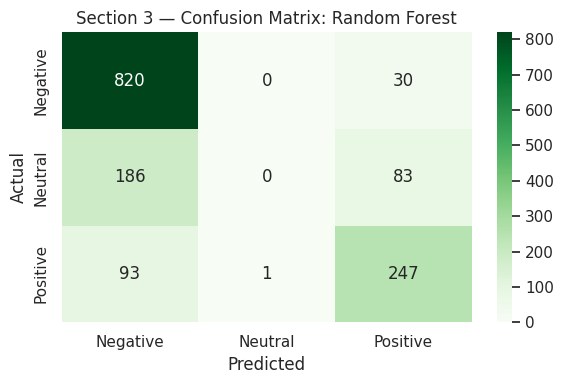

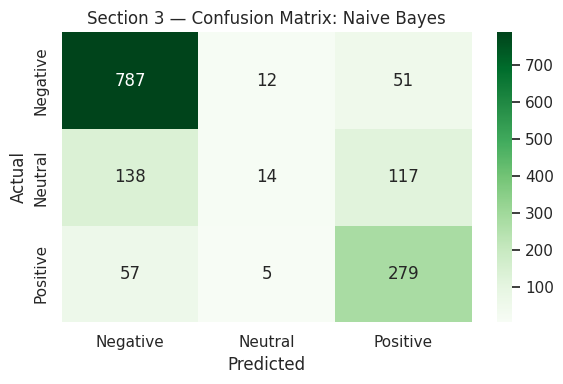

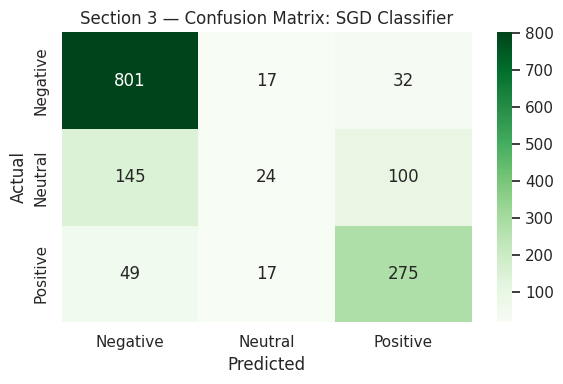

In [ ]:
for name, model in models3.items():
    y_pred = model.predict(X3_test_final)
    cm = confusion_matrix(y3_test, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=le3.classes_,
                yticklabels=le3.classes_)
    plt.title(f'Section 3 — Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()


# GRAND COMPARISON — All 3 Datasets


GRAND COMPARISON — BEST MODEL PER DATASET
                                      Best Model  Accuracy  Precision  Recall      F1
Dataset                                                                              
Section 1 - Skytrax          Logistic Regression    0.6931     0.6758  0.6931  0.6798
Section 2 - British Airways  Logistic Regression    0.6509     0.6429  0.6509  0.6437
Section 3 - Global Airlines  Logistic Regression    0.7527     0.7132  0.7527  0.7189


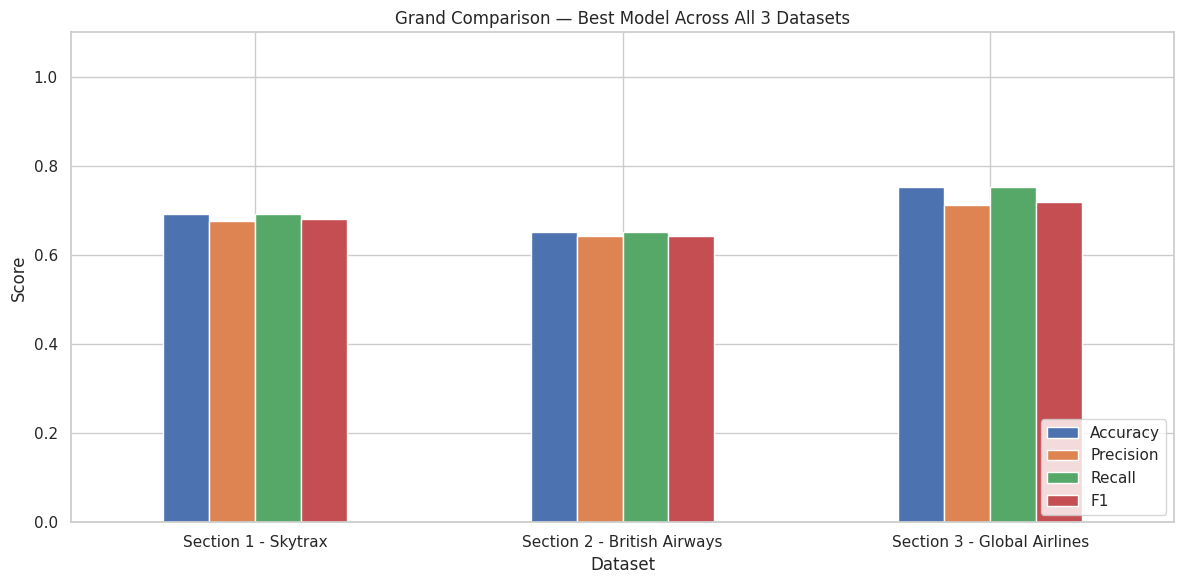

In [ ]:

grand_df = pd.DataFrame({
    'Dataset'  : ['Section 1 - Skytrax',
                  'Section 2 - British Airways',
                  'Section 3 - Global Airlines'],
    'Best Model': [results1_df.index[0],
                   results2_df.index[0],
                   results3_df.index[0]],
    'Accuracy'  : [results1_df['Accuracy'].iloc[0],
                   results2_df['Accuracy'].iloc[0],
                   results3_df['Accuracy'].iloc[0]],
    'Precision' : [results1_df['Precision'].iloc[0],
                   results2_df['Precision'].iloc[0],
                   results3_df['Precision'].iloc[0]],
    'Recall'    : [results1_df['Recall'].iloc[0],
                   results2_df['Recall'].iloc[0],
                   results3_df['Recall'].iloc[0]],
    'F1'        : [results1_df['F1'].iloc[0],
                   results2_df['F1'].iloc[0],
                   results3_df['F1'].iloc[0]],
}).set_index('Dataset').round(4)

print("=" * 60)
print("GRAND COMPARISON — BEST MODEL PER DATASET")
print("=" * 60)
print(grand_df.to_string())

grand_df[['Accuracy','Precision','Recall','F1']].plot(
    kind='bar', figsize=(12, 6),
    ylim=(0, 1.1))
plt.title('Grand Comparison — Best Model Across All 3 Datasets')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


=== Combined Results Across All Datasets ===
                  Model  Accuracy  Precision    Recall        F1          Dataset
0   Logistic Regression  0.693073   0.675825  0.693073  0.679795          Skytrax
1         Decision Tree  0.600000   0.569380  0.600000  0.574047          Skytrax
2         Random Forest  0.646474   0.623909  0.646474  0.560726          Skytrax
3           Naive Bayes  0.648741   0.620604  0.648741  0.615417          Skytrax
4        SGD Classifier  0.670025   0.679014  0.670025  0.582807          Skytrax
5   Logistic Regression  0.650880   0.642909  0.650880  0.643670  British Airways
6         Decision Tree  0.546685   0.532160  0.546685  0.524721  British Airways
7         Random Forest  0.623816   0.605403  0.623816  0.585249  British Airways
8           Naive Bayes  0.627876   0.602167  0.627876  0.596255  British Airways
9        SGD Classifier  0.622463   0.617244  0.622463  0.619249  British Airways
10  Logistic Regression  0.752740   0.713153  0.7527

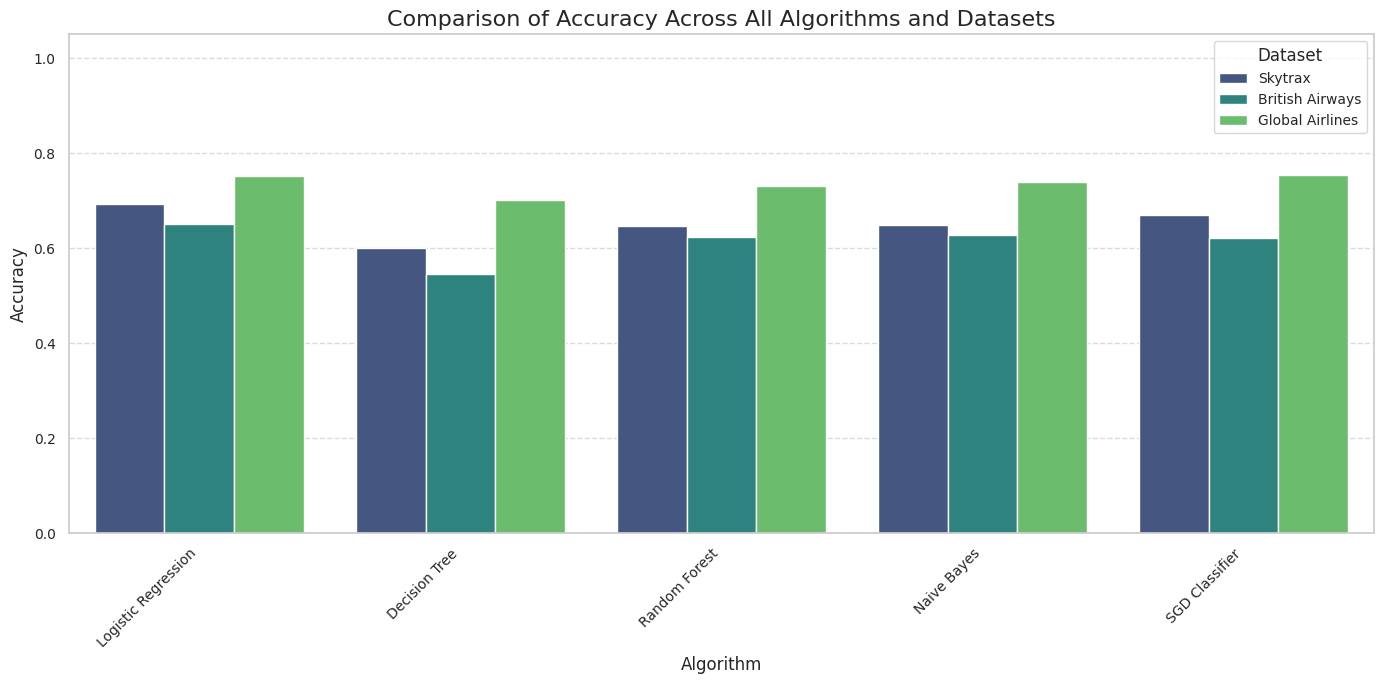

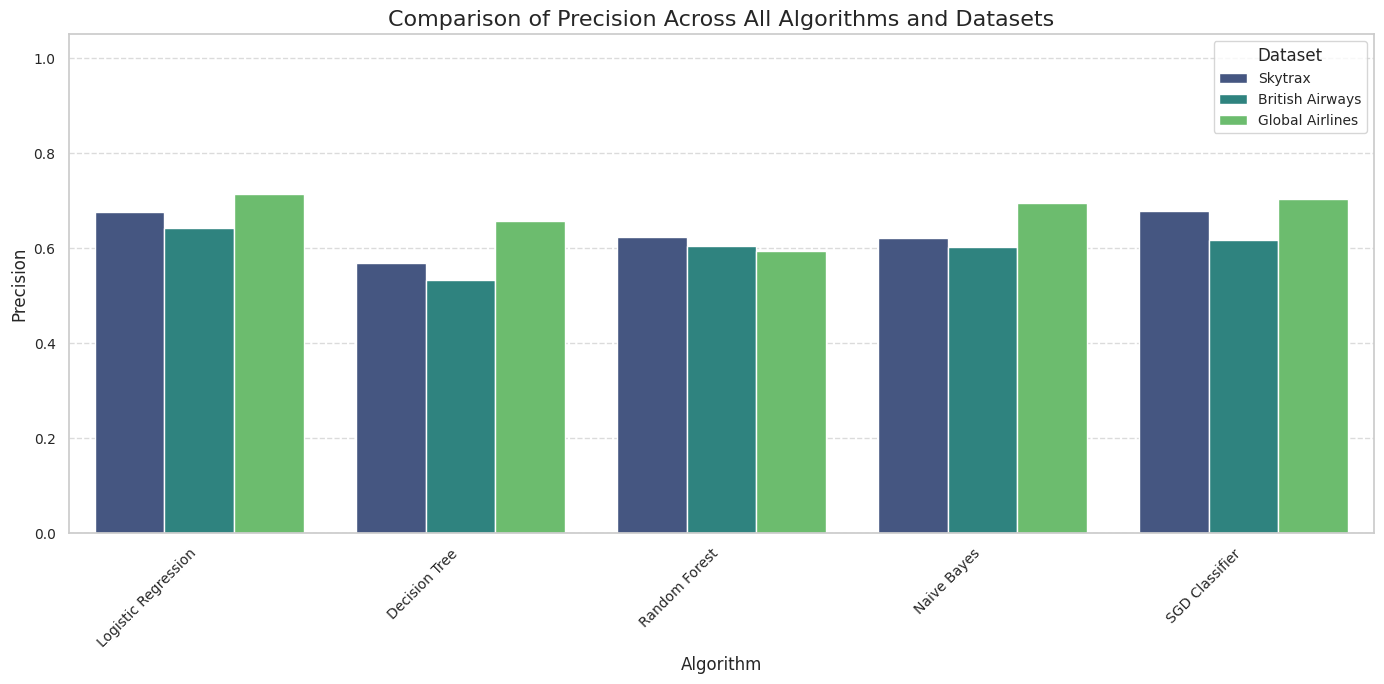

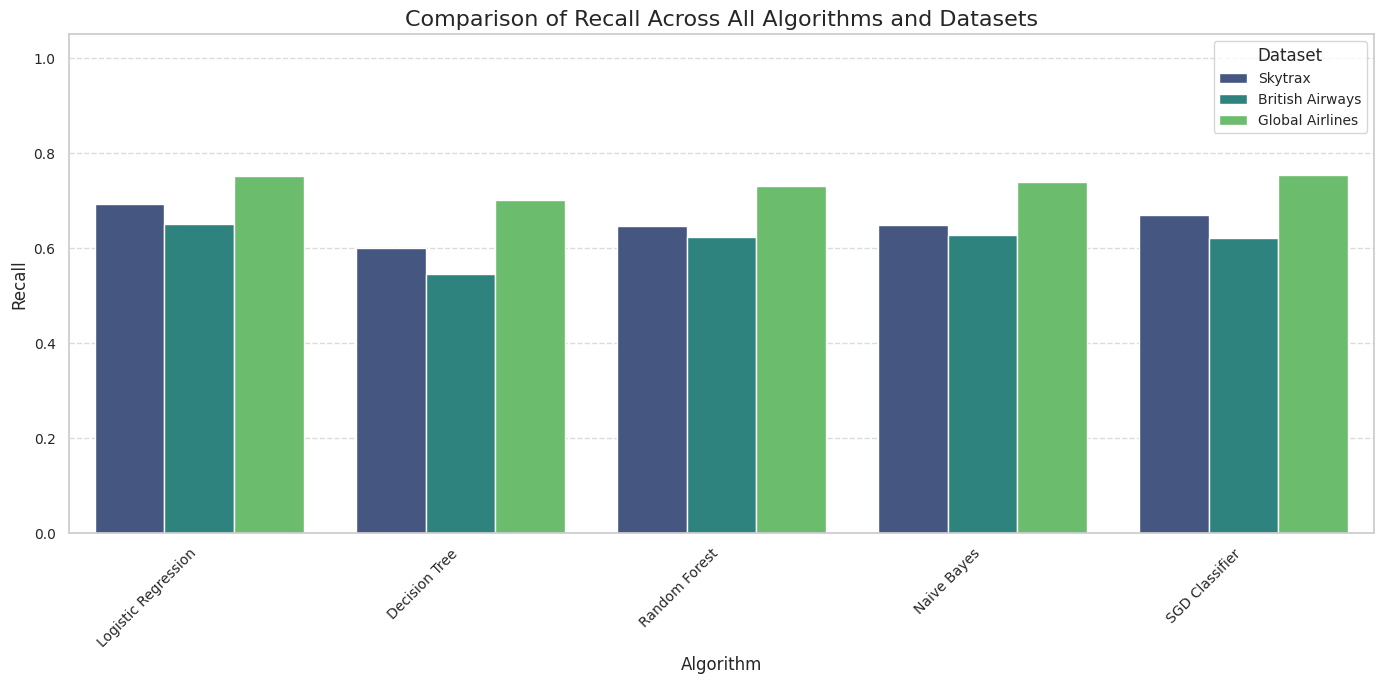

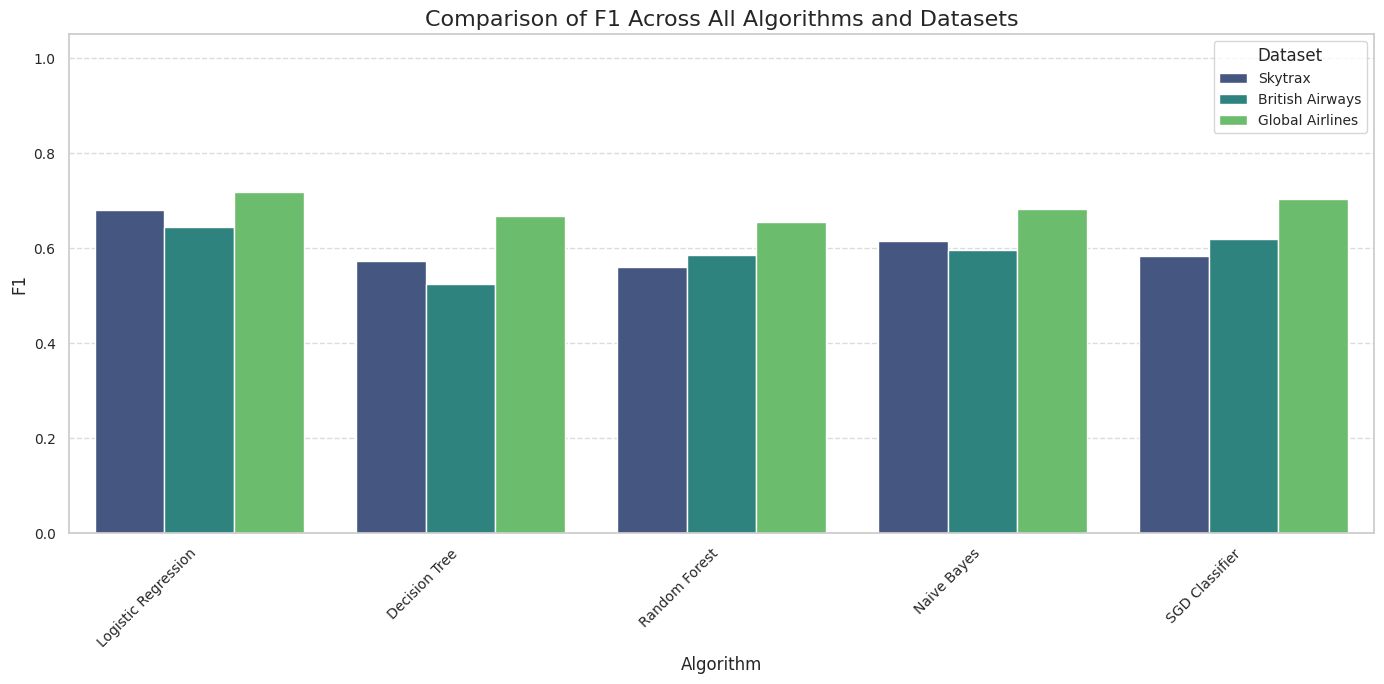

In [ ]:
all_results = []

for r in results1:
    r_copy = r.copy()
    r_copy['Dataset'] = 'Skytrax'
    all_results.append(r_copy)

for r in results2:
    r_copy = r.copy()
    r_copy['Dataset'] = 'British Airways'
    all_results.append(r_copy)

for r in results3:
    r_copy = r.copy()
    r_copy['Dataset'] = 'Global Airlines'
    all_results.append(r_copy)

combined_df = pd.DataFrame(all_results)

print("\n=== Combined Results Across All Datasets ===")
print(combined_df.to_string())

metrics_df = combined_df.melt(id_vars=['Dataset', 'Model'],
                              var_name='Metric',
                              value_name='Score')

performance_metrics_df = metrics_df[metrics_df['Metric'].isin(['Accuracy', 'Precision', 'Recall', 'F1'])]

for metric in ['Accuracy', 'Precision', 'Recall', 'F1']:
    plt.figure(figsize=(14, 7))
    sns.barplot(data=performance_metrics_df[performance_metrics_df['Metric'] == metric],
                x='Model', y='Score', hue='Dataset', palette='viridis')
    plt.title(f'Comparison of {metric} Across All Algorithms and Datasets', fontsize=16)
    plt.xlabel('Algorithm', fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.ylim(0, 1.05)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(title='Dataset', fontsize=10, title_fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()